# 기본 라이브러리

In [1]:
import importlib
from urllib.request import urlretrieve

urlretrieve("https://raw.githubusercontent.com/c0z0c/jupyter_hangul/refs/heads/beta/helper_utils.py", "helper_utils.py")
import helper_utils as hu
from helper_utils import *

urlretrieve("https://raw.githubusercontent.com/c0z0c/jupyter_hangul/refs/heads/beta/helper_c0z0c_dev.py", "helper_c0z0c_dev.py")
import importlib
import helper_c0z0c_dev as helper

helper = importlib.reload(helper)
from helper_c0z0c_dev import *

hu = importlib.reload(hu)
from helper_utils import *

helper_utils.py loaded
🌐 https://c0z0c.github.io/jupyter_hangul
ℹ️ NumPy 2.2.6 (v2.x+): 호환성 모드 적용됨
✅ 설정 완료: 한글 폰트, plt 전역 등록, pandas 확장, 캐시 기능
pd commit 저장 경로 = d:\GoogleDrive\homepage\sprint_mission\DACON\운수종사자
🌐 https://c0z0c.github.io/jupyter_hangul
ℹ️ NumPy 2.2.6 (v2.x+): 호환성 모드 적용됨
✅ 설정 완료: 한글 폰트, plt 전역 등록, pandas 확장, 캐시 기능
pd commit 저장 경로 = d:\GoogleDrive\homepage\sprint_mission\DACON\운수종사자
helper_utils.py loaded


In [2]:
# !pip install lightgbm xgboost --upgrade --quiet

In [3]:
# --- 기본 라이브러리 ---
import importlib
import json
import logging
import math
import os
import random
import re
import shutil
import sys
import time
import warnings
import xml.etree.ElementTree as ET
import yaml
from dataclasses import dataclass, field
from datetime import datetime, timedelta, timezone
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

# --- 데이터 분석 ---
import joblib
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# --- 머신러닝: Scikit-learn ---
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve
    
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- 머신러닝: Gradient Boosting ---
import lightgbm as lgb
import xgboost as xgb

# --- 경고 무시 ---
warnings.filterwarnings('ignore')

# --- 로깅 설정 ---
logger = logging.getLogger(__name__)
logger.setLevel(logging.DEBUG)
# logger.setLevel(logging.INFO)
logger.info(f"라이브러리 로드 완료")

2025-11-10 21:45:17 [I] 라이브러리 로드 완료


In [4]:
PROCESS={}
PROCESS['train_A_기본정보'] = True


In [5]:
drive_temp_path = get_path_temp()
os.makedirs(drive_temp_path, exist_ok=True)
temp_open_v2_clean_path = os.path.join(drive_temp_path, r'open_v2_clean.zip')
unzip_open_v2_clean_path = temp_open_v2_clean_path + '.unzip'

logger.info(f"temp path: {drive_temp_path}")
logger.info(f"temp download path: {temp_open_v2_clean_path}")

if not Path(temp_open_v2_clean_path).exists():
    url_clean_zip = r'https://fs.mybox.naver.com/file/download.api?resourceKey=YzB6MGN8MzQ3MjU5ODEwNDQyMTU1MDQzMnxGfDA&svcType=MYBOX-WEB&time=1762682287910'
    download_http(url_clean_zip, temp_open_v2_clean_path, ignore=False)
    
if not Path(unzip_open_v2_clean_path).exists():
    unzip([temp_open_v2_clean_path])
    
logger.info(f"unzip path: {unzip_open_v2_clean_path}")

train_A_jsonl_path = str(Path(unzip_open_v2_clean_path) / f'train_A_.jsonl')
train_B_jsonl_path = str(Path(unzip_open_v2_clean_path) / f'train_A_.jsonl')
test_A_jsonl_path = str(Path(unzip_open_v2_clean_path) / f'test_A_.jsonl')
test_B_jsonl_path = str(Path(unzip_open_v2_clean_path) / f'test_B_.jsonl')

logger.info(f"train_A_jsonl_path: {Path(train_A_jsonl_path).exists()} {train_A_jsonl_path}")
logger.info(f"train_B_jsonl_path: {Path(train_B_jsonl_path).exists()} {train_B_jsonl_path}")
logger.info(f"test_A_jsonl_path: {Path(test_A_jsonl_path).exists()} {test_A_jsonl_path}")
logger.info(f"test_B_jsonl_path: {Path(test_B_jsonl_path).exists()} {test_B_jsonl_path}")

2025-11-10 21:45:17 [I] temp path: d:\temp
2025-11-10 21:45:17 [I] temp download path: d:\temp\open_v2_clean.zip
2025-11-10 21:45:17 [I] unzip path: d:\temp\open_v2_clean.zip.unzip
2025-11-10 21:45:17 [I] train_A_jsonl_path: True d:\temp\open_v2_clean.zip.unzip\train_A_.jsonl
2025-11-10 21:45:17 [I] train_B_jsonl_path: True d:\temp\open_v2_clean.zip.unzip\train_A_.jsonl
2025-11-10 21:45:17 [I] test_A_jsonl_path: True d:\temp\open_v2_clean.zip.unzip\test_A_.jsonl
2025-11-10 21:45:17 [I] test_B_jsonl_path: True d:\temp\open_v2_clean.zip.unzip\test_B_.jsonl


In [6]:
if PROCESS['train_A_기본정보']:
    df_train_A = pd.read_json(train_A_jsonl_path, orient='records', lines=True)
    df_train_B = pd.read_json(train_B_jsonl_path, orient='records', lines=True)

In [7]:
# 컬럼 한글 약자 매핑
col_kr_dict_A = {
    # 기본 정보
    'TestDate': '검사일',
    'Label': '레이블',
    
    # A1: 좌우 방향 판단 (Left/Right)
    'A1L_fail_rate': 'A1좌_실패율',
    'A1L_mean_error': 'A1좌_평균오차',
    'A1L_fast_fail': 'A1좌_조급실패',
    'A1L_std': 'A1좌_표준편차',
    'A1R_fail_rate': 'A1우_실패율',
    'A1R_mean_error': 'A1우_평균오차',
    'A1R_fast_fail': 'A1우_조급실패',
    'A1R_std': 'A1우_표준편차',
    'A1_direction_diff': 'A1_방향차이',
    
    # A2: 속도 조절 (Constant/Accel/Decel)
    'A2_constant_fail': 'A2_일정실패',
    'A2_constant_error': 'A2_일정오차',
    'A2_accel_fail': 'A2_가속실패',
    'A2_accel_error': 'A2_가속오차',
    'A2_decel_fail': 'A2_감속실패',
    'A2_decel_error': 'A2_감속오차',
    'A2_total_fail': 'A2_전체실패',
    'A2_mean_error': 'A2_평균오차',
    'A2_std': 'A2_표준편차',
    
    # A3: 시야 범위 (Small/Big, Valid/Invalid)
    'A3S_correct_rate': 'A3소_정답률',
    'A3S_fail_rate': 'A3소_실패율',
    'A3S_mean_rt': 'A3소_평균반응시간',
    'A3B_correct_rate': 'A3대_정답률',
    'A3B_fail_rate': 'A3대_실패율',
    'A3B_mean_rt': 'A3대_평균반응시간',
    'A3_valid_correct': 'A3_유효정답',
    'A3_valid_fail_rate': 'A3_유효실패율',
    'A3_invalid_correct': 'A3_무효정답',
    'A3_invalid_fail_rate': 'A3_무효실패율',
    'A3_size_diff': 'A3_크기차이',
    'A3_valid_invalid_diff': 'A3_유무효차이',
    'A3_total_fail': 'A3_전체실패',
    'A3_mean_rt': 'A3_평균반응시간',
    
    # A4: Stroop 효과 (Congruent/Incongruent)
    'A4C_correct_rate': 'A4일치_정답률',
    'A4C_fail_rate': 'A4일치_실패율',
    'A4C_mean_rt': 'A4일치_평균반응시간',
    'A4I_correct_rate': 'A4불일치_정답률',
    'A4I_fail_rate': 'A4불일치_실패율',
    'A4I_mean_rt': 'A4불일치_평균반응시간',
    'A4_stroop_effect': 'A4_스트룹효과',
    'A4_total_correct': 'A4_전체정답',
    'A4_total_fail': 'A4_전체실패',
    'A4_mean_rt': 'A4_평균반응시간',
    
    # A5: 변화 탐지
    'A5_no_change_correct': 'A5_무변화정답',
    'A5_change_correct': 'A5_변화정답',
    'A5_sensitivity': 'A5_민감도',
    'A5_total_fail': 'A5_전체실패',
    
    # A6: 정확도 평가
    'A6_correct_count': 'A6_정답수',
    'A6_accuracy': 'A6_정확도',
    'A6_incorrect_count': 'A6_오답수',
    'A6_acc_level': 'A6_정확도레벨',
    
    # A7: 정확도 평가2
    'A7_correct_count': 'A7_정답수',
    'A7_accuracy': 'A7_정확도',
    'A7_incorrect_count': 'A7_오답수',
    'A7_acc_level': 'A7_정확도레벨',
    'A7_performance': 'A7_수행수준',
    
    # A8: 왜곡도/일관성
    'A8_distortion_score': 'A8_왜곡점수',
    'A8_consistency_score': 'A8_일관성점수',
    'A8_distortion_norm': 'A8_왜곡표준',
    'A8_consistency_norm': 'A8_일관성표준',
    'A8_distortion_high': 'A8_고왜곡여부',
    'A8_consistency_good': 'A8_양호일관성',
    'A8_validity_score': 'A8_타당도점수',
    'A8_test_reliable': 'A8_검사신뢰여부',
    
    # A9: 반응시간 상세 (Go/NoGo)
    'A9_rt_mean': 'A9_반응평균',
    'A9_rt_std': 'A9_반응표준편차',
    'A9_rt_cv': 'A9_반응변이계수',
    'A9_rt_min': 'A9_반응최소',
    'A9_rt_max': 'A9_반응최대',
    'A9_rt_q25': 'A9_반응1사분위',
    'A9_rt_q75': 'A9_반응3사분위',
    'A9_accuracy': 'A9_정확도',
    'A9_go_rt': 'A9_고반응시간',
    'A9_go_acc': 'A9_고정확도',
    'A9_go_miss': 'A9_고누락',
    'A9_nogo_acc': 'A9_노고정확도',
    'A9_nogo_commission': 'A9_노고오반응',
    'A9_nogo_rt': 'A9_노고반응시간',
    'A9_cond1_rt': 'A9_조건1반응시간',
    'A9_cond1_acc': 'A9_조건1정확도',
    'A9_cond2_rt': 'A9_조건2반응시간',
    'A9_cond2_acc': 'A9_조건2정확도',
    'A9_cond3_rt': 'A9_조건3반응시간',
    'A9_cond3_acc': 'A9_조건3정확도',
    'A9_error_rt': 'A9_오류반응시간',
    'A9_correct_rt': 'A9_정답반응시간',
    'A9_too_fast_cnt': 'A9_과속횟수',
    'A9_too_slow_cnt': 'A9_지체횟수',
    'A9_response_rate': 'A9_반응률',
    'A9_no_response_cnt': 'A9_무반응횟수',
    'A9_false_alarm_rate': 'A9_거짓경보율',
    'A9_impulsivity_index': 'A9_충동성지수'
}

# 역방향 매핑 (한글 -> 영문)
col_en_dict_A = {v: k for k, v in col_kr_dict_A.items()}

if PROCESS['train_A_기본정보']:
    df_train_A.set_head_att(col_kr_dict_A)
    df_train_A.describe().head_att(10)
    df_train_A.head_att(10)

            검사일 레이블   A1좌_실패율  A1좌_평균오차 A1좌_조급실패 A1좌_표준편차   A1우_실패율  A1우_평균오차 A1우_조급실패 A1우_표준편차       A1_방향차이      A2_일정실패       A2_일정오차   A2_가속실패    A2_가속오차   A2_감속실패    A2_감속오차   A2_전체실패   A2_평균오차 A2_표준편차      A3소_정답률   A3소_실패율 A3소_평균반응시간      A3대_정답률   A3대_실패율 A3대_평균반응시간      A3_유효정답      A3_유효실패율        A3_무효정답        A3_무효실패율  A3_크기차이         A3_유무효차이   A3_전체실패 A3_평균반응시간    A4일치_정답률 A4일치_실패율 A4일치_평균반응시간  A4불일치_정답률 A4불일치_실패율 A4불일치_평균반응시간    A4_스트룹효과      A4_전체정답   A4_전체실패 A4_평균반응시간        A5_무변화정답       A5_변화정답      A5_민감도   A5_전체실패        A6_정답수   A6_정확도          A6_오답수 A6_정확도레벨        A7_정답수   A7_정확도          A7_오답수 A7_정확도레벨         A8_왜곡점수        A8_일관성점수        A8_왜곡표준       A8_일관성표준      A8_고왜곡여부       A8_양호일관성     A8_타당도점수  A8_검사신뢰여부 A9_반응평균 A9_반응표준편차 A9_반응변이계수 A9_반응최소 A9_반응최대 A9_반응1사분위 A9_반응3사분위   A9_정확도 A9_고반응시간 A9_고정확도  A9_고누락 A9_노고정확도      A9_노고오반응 A9_노고반응시간 A9_조건1반응시간 A9_조건1정확도 A9_조건2반응시간 A9_조건2정확도 A9_조건3반응시간 A9_조건3정확도 A9_오류반응시간 A9_정답반응시간     A9_과속횟수     A9_지체횟수        A

In [ ]:
"""
운수종사자 적성검사 분석 프로젝트 설정
Config for Transport Worker Aptitude Test Analysis Project
"""

# from dataclasses import dataclass, field
# from typing import List, Dict, Optional
# from pathlib import Path

@dataclass
class DataConfig:
    """데이터 관련 설정"""
    
    sample_test_size: Optional[int] = None  # 샘플 테스트용 데이터 크기 제한 (None이면 전체 사용)
    # sample_test_size: Optional[int] = 100
    
    # 파일 경로
    data_path: str = train_A_jsonl_path
    output_dir: str = str(Path(get_path_modeling()) / 'driver_aptitude')
    
    # 데이터 분할 비율
    train_ratio: float = 0.8
    val_ratio: float = 0.1
    test_ratio: float = 0.1
    
    # 시드
    random_seed: int = 42
    
    # 타겟 컬럼
    target_col: str = "Label"
    
    # 제외할 컬럼 (ID, 날짜 등)
    exclude_cols: List[str] = field(default_factory=lambda: [
        "Test_id_idx", "PrimaryKey", "Test", "TestDate"
    ])
    
    # A검사별 피처 그룹
    feature_groups: Dict[str, List[str]] = field(default_factory=lambda: {
        "A1": ["A1L_fail_rate", "A1L_mean_error", "A1L_fast_fail", "A1L_std",
               "A1R_fail_rate", "A1R_mean_error", "A1R_fast_fail", "A1R_std",
               "A1_direction_diff"],
        "A2": ["A2_constant_fail", "A2_constant_error", "A2_accel_fail", 
               "A2_accel_error", "A2_decel_fail", "A2_decel_error", 
               "A2_total_fail", "A2_mean_error", "A2_std"],
        "A3": ["A3S_correct_rate", "A3S_fail_rate", "A3S_mean_rt",
               "A3B_correct_rate", "A3B_fail_rate", "A3B_mean_rt",
               "A3_valid_correct", "A3_valid_fail_rate", "A3_invalid_correct",
               "A3_invalid_fail_rate", "A3_size_diff", "A3_valid_invalid_diff",
               "A3_total_fail", "A3_mean_rt"],
        "A4": ["A4C_correct_rate", "A4C_fail_rate", "A4C_mean_rt",
               "A4I_correct_rate", "A4I_fail_rate", "A4I_mean_rt",
               "A4_stroop_effect", "A4_total_correct", "A4_total_fail", "A4_mean_rt"],
        "A5": ["A5_no_change_correct", "A5_change_correct", 
               "A5_sensitivity", "A5_total_fail"],
        "A6": ["A6_correct_count", "A6_accuracy", "A6_incorrect_count", "A6_acc_level"],
        "A7": ["A7_correct_count", "A7_accuracy", "A7_incorrect_count", 
               "A7_acc_level", "A7_performance"],
        "A8": ["A8_distortion_score", "A8_consistency_score", "A8_distortion_norm",
               "A8_consistency_norm", "A8_distortion_high", "A8_consistency_good",
               "A8_validity_score", "A8_test_reliable"],
        "A9": ["A9_rt_mean", "A9_rt_std", "A9_rt_cv", "A9_rt_min", "A9_rt_max",
               "A9_rt_q25", "A9_rt_q75", "A9_accuracy", "A9_go_rt", "A9_go_acc",
               "A9_go_miss", "A9_nogo_acc", "A9_nogo_commission", "A9_nogo_rt",
               "A9_cond1_rt", "A9_cond1_acc", "A9_cond2_rt", "A9_cond2_acc",
               "A9_cond3_rt", "A9_cond3_acc", "A9_error_rt", "A9_correct_rt",
               "A9_too_fast_cnt", "A9_too_slow_cnt", "A9_response_rate",
               "A9_no_response_cnt", "A9_false_alarm_rate", "A9_impulsivity_index"]
    })


@dataclass
class ModelConfig:
    """모델 관련 설정"""
    # 모델 타입
    model_type: str = "lightgbm"  # lightgbm, xgboost, random_forest, logistic
    
    # LightGBM 하이퍼파라미터
    lgb_params: Dict = field(default_factory=lambda: {
        "objective": "binary",
        "metric": "auc",
        "boosting_type": "gbdt",
        "num_leaves": 31,
        "learning_rate": 0.05,
        "feature_fraction": 0.9,
        "bagging_fraction": 0.8,
        "bagging_freq": 5,
        "max_depth": -1,
        "min_child_samples": 20,
        "verbose": -1,
        "random_state": 42
    })
    
    # XGBoost 하이퍼파라미터
    xgb_params: Dict = field(default_factory=lambda: {
        "objective": "binary:logistic",
        "eval_metric": "auc",
        "max_depth": 6,
        "learning_rate": 0.05,
        "subsample": 0.8,
        "colsample_bytree": 0.9,
        "min_child_weight": 1,
        "random_state": 42
    })
    
    # RandomForest 하이퍼파라미터
    rf_params: Dict = field(default_factory=lambda: {
        "n_estimators": 100,
        "max_depth": 10,
        "min_samples_split": 10,
        "min_samples_leaf": 4,
        "random_state": 42,
        "n_jobs": -1
    })


@dataclass
class TrainingConfig:
    """학습 관련 설정"""
    # 학습 파라미터
    num_boost_round: int = 1000
    early_stopping_rounds: int = 50
    verbose_eval: int = 50
    
    # 교차 검증
    use_cross_validation: bool = False
    n_folds: int = 5
    
    # 클래스 불균형 처리
    handle_imbalance: bool = True
    scale_pos_weight: Optional[float] = None  # None이면 자동 계산


@dataclass
class VisualizationConfig:
    """시각화 관련 설정"""
    # 그래프 저장 설정
    save_plots: bool = True
    plot_format: str = "png"
    dpi: int = 300
    
    # 그래프 스타일
    style: str = "seaborn-v0_8-darkgrid"
    figsize: tuple = (12, 8)
    
    # 한글 폰트 설정
    use_korean_font: bool = True
    font_family: str = "DejaVu Sans"


@dataclass
class ProjectConfig:
    """전체 프로젝트 설정"""
    # 프로젝트 정보
    project_name: str = "운수종사자_적성검사_분석"
    version: str = "1.0.0"
    
    # 하위 설정
    data: DataConfig = field(default_factory=DataConfig)
    model: ModelConfig = field(default_factory=ModelConfig)
    training: TrainingConfig = field(default_factory=TrainingConfig)
    visualization: VisualizationConfig = field(default_factory=VisualizationConfig)
    
    def __post_init__(self):
        """설정 초기화 후 디렉토리 생성"""
        Path(self.data.output_dir).mkdir(parents=True, exist_ok=True)
        Path(f"{self.data.output_dir}/plots").mkdir(exist_ok=True)
        Path(f"{self.data.output_dir}/models").mkdir(exist_ok=True)
        Path(f"{self.data.output_dir}/reports").mkdir(exist_ok=True)
    
    def get_feature_list(self) -> List[str]:
        """모든 피처 리스트 반환"""
        all_features = []
        for features in self.data.feature_groups.values():
            all_features.extend(features)
        return all_features
    
    def print_config(self):
        """설정 출력"""
        logger.debug(f"{'='*60}")
        logger.debug(f"Project: {self.project_name} v{self.version}")
        logger.debug(f"{'='*60}")
        logger.debug(f"\n[Data Config]")
        logger.debug(f"  - Data path: {self.data.data_path}")
        logger.debug(f"  - Train/Val/Test: {self.data.train_ratio}/{self.data.val_ratio}/{self.data.test_ratio}")
        logger.debug(f"  - Random seed: {self.data.random_seed}")
        logger.debug(f"\n[Model Config]")
        logger.debug(f"  - Model type: {self.model.model_type}")
        logger.debug(f"\n[Training Config]")
        logger.debug(f"  - Num boost round: {self.training.num_boost_round}")
        logger.debug(f"  - Early stopping: {self.training.early_stopping_rounds}")
        logger.debug(f"  - Cross validation: {self.training.use_cross_validation}")
        logger.debug(f"{'='*60}\n")

def test_config():
    # 전역 설정 인스턴스
    config = ProjectConfig()
    
    # 설정 테스트
    config.print_config()
    logger.debug(f"Total features: {len(config.get_feature_list())}")
    logger.debug(f"\nFeature groups:")
    for group_name, features in config.data.feature_groups.items():
        logger.debug(f"  {group_name}: {len(features)} features")
    
    return config
config = test_config()

2025-11-10 21:47:46 [D] ============================================================
2025-11-10 21:47:46 [D] Project: 운수종사자_적성검사_분석 v1.0.0
2025-11-10 21:47:46 [D] ============================================================
2025-11-10 21:47:46 [D] 
[Data Config]
2025-11-10 21:47:46 [D]   - Data path: d:\temp\open_v2_clean.zip.unzip\train_A_.jsonl
2025-11-10 21:47:46 [D]   - Train/Val/Test: 0.8/0.1/0.1
2025-11-10 21:47:46 [D]   - Random seed: 42
2025-11-10 21:47:46 [D] 
[Model Config]
2025-11-10 21:47:46 [D]   - Model type: lightgbm
2025-11-10 21:47:46 [D] 
[Training Config]
2025-11-10 21:47:46 [D]   - Num boost round: 1000
2025-11-10 21:47:46 [D]   - Early stopping: 50
2025-11-10 21:47:46 [D]   - Cross validation: False
2025-11-10 21:47:46 [D] ============================================================

2025-11-10 21:47:46 [D] Total features: 91
2025-11-10 21:47:46 [D] 
Feature groups:
2025-11-10 21:47:46 [D]   A1: 9 features
2025-11-10 21:47:46 [D]   A2: 9 features
2025-11-10 21:47:4

In [13]:
"""
데이터 로드 및 전처리 파이프라인
Data Loading and Preprocessing Pipeline
"""

# import json
# import pandas as pd
# import numpy as np
# from pathlib import Path
# from typing import Tuple, Optional, Dict, List
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler
# import warnings
# warnings.filterwarnings('ignore')


class DataLoader:
    """운수종사자 적성검사 데이터 로더"""
    
    def __init__(self, config):
        """
        Args:
            config: ProjectConfig 인스턴스
        """
        self.config = config
        self.data = None
        self.train_data = None
        self.val_data = None
        self.test_data = None
        self.scaler = StandardScaler()
        
    def load_json_data(self, file_path: Optional[str] = None) -> pd.DataFrame:
        """
        JSON 데이터 로드 (샘플 테스트 지원)
        
        Args:
            file_path: 데이터 파일 경로 (None이면 config에서 가져옴)
            
        Returns:
            pd.DataFrame: 로드된 데이터프레임
        """
        if file_path is None:
            file_path = self.config.data.data_path
            
        logger.debug(f"Loading data from: {file_path}")
        
        # 샘플 테스트 모드 확인
        sample_size = self.config.data.sample_test_size
        if sample_size is not None:
            logger.warning(f"⚠ SAMPLE TEST MODE: Loading only {sample_size} samples")
        
        # pandas가 자동으로 JSONL 형식 감지
        df = pd.read_json(file_path, lines=True)
                    
        # 샘플 크기 제한 (Stratified Sampling)
        if sample_size is not None and len(df) > sample_size:
            target_col = self.config.data.target_col
            
            # Label 분포 확인
            label_counts = df[target_col].value_counts()
            logger.warning(f"  ⚠ Original label distribution: {label_counts.to_dict()}")
            
            # 균등 샘플링: 각 Label당 절반씩
            samples_per_label = sample_size // len(label_counts)
            
            df_balanced = []
            for label in sorted(label_counts.index):
                df_label = df[df[target_col] == label]
                
                # 해당 Label 샘플 수가 부족하면 전체 사용
                n_samples = min(samples_per_label, len(df_label))
                
                df_sampled = df_label.sample(
                    n=n_samples,
                    random_state=self.config.data.random_seed
                )
                df_balanced.append(df_sampled)
            
            df = pd.concat(df_balanced, ignore_index=True)
            
            # 샘플링 후 Label 분포 확인
            sampled_label_counts = df[target_col].value_counts()
            logger.warning(f"  ⚠ Balanced sampling: {len(df)} rows")
            logger.warning(f"  ⚠ Sampled label distribution: {sampled_label_counts.to_dict()}")
            logger.warning(f"  ⚠ Label 0: {sampled_label_counts.get(0, 0)}")
            logger.warning(f"  ⚠ Label 1: {sampled_label_counts.get(1, 0)}")
        
        logger.debug(f"✓ Data loaded successfully: {df.shape}")
        self.data = df
        return df

    
    def preprocess_data(self, df: Optional[pd.DataFrame] = None) -> pd.DataFrame:
        """
        데이터 전처리
        
        Args:
            df: 전처리할 데이터프레임 (None이면 self.data 사용)
            
        Returns:
            pd.DataFrame: 전처리된 데이터프레임
        """
        if df is None:
            df = self.data.copy()
        else:
            df = df.copy()
        
        logger.debug("\nPreprocessing data...")
        
        # 1. 제외 컬럼 제거
        cols_to_drop = [col for col in self.config.data.exclude_cols if col in df.columns]
        if cols_to_drop:
            df = df.drop(columns=cols_to_drop)
            logger.debug(f"  - Dropped columns: {cols_to_drop}")
        
        # 2. 결측치 확인
        missing_counts = df.isnull().sum()
        if missing_counts.sum() > 0:
            logger.debug(f"  - Missing values found:")
            for col, count in missing_counts[missing_counts > 0].items():
                logger.debug(f"    {col}: {count} ({count/len(df)*100:.2f}%)")
            
            # 수치형 컬럼은 평균으로, 범주형은 최빈값으로 대체
            for col in df.columns:
                if df[col].isnull().sum() > 0:
                    if df[col].dtype in ['float64', 'int64']:
                        df[col].fillna(df[col].mean(), inplace=True)
                    else:
                        df[col].fillna(df[col].mode()[0], inplace=True)
        else:
            logger.debug("  - No missing values found")
        
        # 3. 무한대 값 처리
        numeric_cols = df.select_dtypes(include=[np.number]).columns
        for col in numeric_cols:
            if np.isinf(df[col]).any():
                logger.debug(f"  - Found inf values in {col}, replacing with max/min")
                df[col].replace([np.inf, -np.inf], [df[col][~np.isinf(df[col])].max(), 
                                                     df[col][~np.isinf(df[col])].min()], 
                               inplace=True)
        
        # 4. 범주형 변수 인코딩 (A7_performance 등)
        categorical_cols = df.select_dtypes(include=['object']).columns
        categorical_cols = [col for col in categorical_cols if col != self.config.data.target_col]
        
        if len(categorical_cols) > 0:
            logger.debug(f"  - Encoding categorical columns: {list(categorical_cols)}")
            for col in categorical_cols:
                df[col] = pd.Categorical(df[col]).codes
        
        logger.debug(f"✓ Preprocessing completed: {df.shape}")
        self.data = df
        return df
    
    def split_data(self, 
                   df: Optional[pd.DataFrame] = None,
                   stratify: bool = True) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
        """
        데이터를 train/val/test로 분할 (Label 기준 균등 분배)
        
        Args:
            df: 분할할 데이터프레임 (None이면 self.data 사용)
            stratify: 층화 추출 여부 (Label 비율 유지)
            
        Returns:
            Tuple[train_df, val_df, test_df]
        """
        if df is None:
            df = self.data.copy()
        else:
            df = df.copy()
        
        logger.debug("\nSplitting data...")
        
        target_col = self.config.data.target_col
        train_ratio = self.config.data.train_ratio
        val_ratio = self.config.data.val_ratio
        test_ratio = self.config.data.test_ratio
        seed = self.config.data.random_seed
        
        # 비율 검증
        assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-6, \
            "Train/Val/Test ratios must sum to 1.0"
        
        # Stratify 설정
        stratify_col = df[target_col] if stratify else None
        
        # 1차 분할: train + (val + test)
        train_df, temp_df = train_test_split(
            df,
            test_size=(val_ratio + test_ratio),
            random_state=seed,
            stratify=stratify_col
        )
        
        # 2차 분할: val + test
        val_ratio_adjusted = val_ratio / (val_ratio + test_ratio)
        stratify_temp = temp_df[target_col] if stratify else None
        
        val_df, test_df = train_test_split(
            temp_df,
            test_size=(1 - val_ratio_adjusted),
            random_state=seed,
            stratify=stratify_temp
        )
        
        # 결과 저장
        self.train_data = train_df
        self.val_data = val_df
        self.test_data = test_df
        
        # 분할 결과 출력
        logger.debug(f"  - Train: {len(train_df)} ({len(train_df)/len(df)*100:.1f}%)")
        logger.debug(f"    Label 0: {(train_df[target_col]==0).sum()}, Label 1: {(train_df[target_col]==1).sum()}")
        logger.debug(f"  - Val:   {len(val_df)} ({len(val_df)/len(df)*100:.1f}%)")
        logger.debug(f"    Label 0: {(val_df[target_col]==0).sum()}, Label 1: {(val_df[target_col]==1).sum()}")
        logger.debug(f"  - Test:  {len(test_df)} ({len(test_df)/len(df)*100:.1f}%)")
        logger.debug(f"    Label 0: {(test_df[target_col]==0).sum()}, Label 1: {(test_df[target_col]==1).sum()}")
        
        return train_df, val_df, test_df
    
    def get_X_y(self, 
                df: pd.DataFrame,
                scale_features: bool = False) -> Tuple[np.ndarray, np.ndarray]:
        """
        피처(X)와 타겟(y) 분리
        
        Args:
            df: 데이터프레임
            scale_features: 피처 스케일링 여부
            
        Returns:
            Tuple[X, y]
        """
        target_col = self.config.data.target_col
        
        # 타겟 분리
        if target_col not in df.columns:
            raise ValueError(f"Target column '{target_col}' not found in dataframe")
        
        y = df[target_col].values
        X = df.drop(columns=[target_col]).values
        
        # 스케일링
        if scale_features:
            X = self.scaler.fit_transform(X)
        
        return X, y
    
    def get_feature_names(self, df: Optional[pd.DataFrame] = None) -> List[str]:
        """
        피처 이름 리스트 반환
        
        Args:
            df: 데이터프레임 (None이면 self.train_data 사용)
            
        Returns:
            List[str]: 피처 이름 리스트
        """
        if df is None:
            df = self.train_data if self.train_data is not None else self.data
        
        target_col = self.config.data.target_col
        return [col for col in df.columns if col != target_col]
    
    def get_data_summary(self) -> Dict:
        """
        데이터 요약 정보 반환
        
        Returns:
            Dict: 데이터 요약 정보
        """
        if self.data is None:
            raise ValueError("No data loaded. Please load data first.")
        
        target_col = self.config.data.target_col
        
        summary = {
            "total_samples": len(self.data),
            "num_features": len(self.get_feature_names()),
            "label_distribution": self.data[target_col].value_counts().to_dict(),
            "label_ratio": f"{(self.data[target_col]==0).sum()}/{(self.data[target_col]==1).sum()}",
            "missing_values": self.data.isnull().sum().sum(),
            "data_types": self.data.dtypes.value_counts().to_dict()
        }
        
        if self.train_data is not None:
            summary["train_samples"] = len(self.train_data)
            summary["val_samples"] = len(self.val_data)
            summary["test_samples"] = len(self.test_data)
        
        return summary
    
    def save_processed_data(self, output_dir: Optional[str] = None):
        """
        전처리된 데이터 저장
        
        Args:
            output_dir: 저장 디렉토리 (None이면 config에서 가져옴)
        """
        if output_dir is None:
            output_dir = self.config.data.output_dir
        
        output_path = Path(output_dir)
        output_path.mkdir(parents=True, exist_ok=True)
        
        if self.train_data is not None:
            self.train_data.to_csv(output_path / "train_processed.csv", index=False)
            self.val_data.to_csv(output_path / "val_processed.csv", index=False)
            self.test_data.to_csv(output_path / "test_processed.csv", index=False)
            logger.debug(f"\n✓ Processed data saved to {output_dir}")
        else:
            logger.debug("\n✗ No split data to save. Please run split_data() first.")


def test_data_loader():
    
    # 데이터 로더 생성
    #config = ProjectConfig()
    loader = DataLoader(config)
    
    # 데이터 로드 테스트 (실제 파일이 있다고 가정)
    df = loader.load_json_data()
    df = loader.preprocess_data()
    train_df, val_df, test_df = loader.split_data()
    
    # 요약 정보 출력
    summary = loader.get_data_summary()
    logger.debug("\n" + "="*60)
    logger.debug("Data Summary:")
    logger.debug("="*60)
    for key, value in summary.items():
        logger.debug(f"{key}: {value}")
    
    # 데이터 저장
    loader.save_processed_data()
    return loader
        
loader = test_data_loader()

2025-11-10 22:05:00 [D] Loading data from: d:\temp\open_v2_clean.zip.unzip\train_A_.jsonl
2025-11-10 22:05:00 [W] ⚠ SAMPLE TEST MODE: Loading only 100 samples
2025-11-10 22:05:31 [W]   ⚠ Original label distribution: {0: 632545, 1: 14692}
2025-11-10 22:05:32 [W]   ⚠ Balanced sampling: 100 rows
2025-11-10 22:05:32 [W]   ⚠ Sampled label distribution: {0: 50, 1: 50}
2025-11-10 22:05:32 [W]   ⚠ Label 0: 50
2025-11-10 22:05:32 [W]   ⚠ Label 1: 50
2025-11-10 22:05:32 [D] ✓ Data loaded successfully: (100, 96)
2025-11-10 22:05:32 [D] 
Preprocessing data...
2025-11-10 22:05:32 [D]   - Dropped columns: ['Test_id_idx', 'PrimaryKey', 'Test', 'TestDate']
2025-11-10 22:05:32 [D]   - No missing values found
2025-11-10 22:05:32 [D]   - Encoding categorical columns: ['A7_performance']
2025-11-10 22:05:32 [D] ✓ Preprocessing completed: (100, 92)
2025-11-10 22:05:32 [D] 
Splitting data...
2025-11-10 22:05:32 [D]   - Train: 80 (80.0%)
2025-11-10 22:05:32 [D]     Label 0: 40, Label 1: 40
2025-11-10 22:05:32

2025-11-10 22:05:32 [D] Loading data from: d:\temp\open_v2_clean.zip.unzip\train_A_.jsonl
2025-11-10 22:05:32 [W] ⚠ SAMPLE TEST MODE: Loading only 100 samples
2025-11-10 22:06:08 [W]   ⚠ Original label distribution: {0: 632545, 1: 14692}
2025-11-10 22:06:09 [W]   ⚠ Balanced sampling: 100 rows
2025-11-10 22:06:09 [W]   ⚠ Sampled label distribution: {0: 50, 1: 50}
2025-11-10 22:06:09 [W]   ⚠ Label 0: 50
2025-11-10 22:06:09 [W]   ⚠ Label 1: 50
2025-11-10 22:06:09 [D] ✓ Data loaded successfully: (100, 96)
2025-11-10 22:06:09 [D] 
Preprocessing data...
2025-11-10 22:06:09 [D]   - Dropped columns: ['Test_id_idx', 'PrimaryKey', 'Test', 'TestDate']
2025-11-10 22:06:09 [D]   - No missing values found
2025-11-10 22:06:09 [D]   - Encoding categorical columns: ['A7_performance']
2025-11-10 22:06:09 [D] ✓ Preprocessing completed: (100, 92)
2025-11-10 22:06:09 [D] 
Splitting data...
2025-11-10 22:06:09 [D]   - Train: 80 (80.0%)
2025-11-10 22:06:09 [D]     Label 0: 40, Label 1: 40
2025-11-10 22:06:09

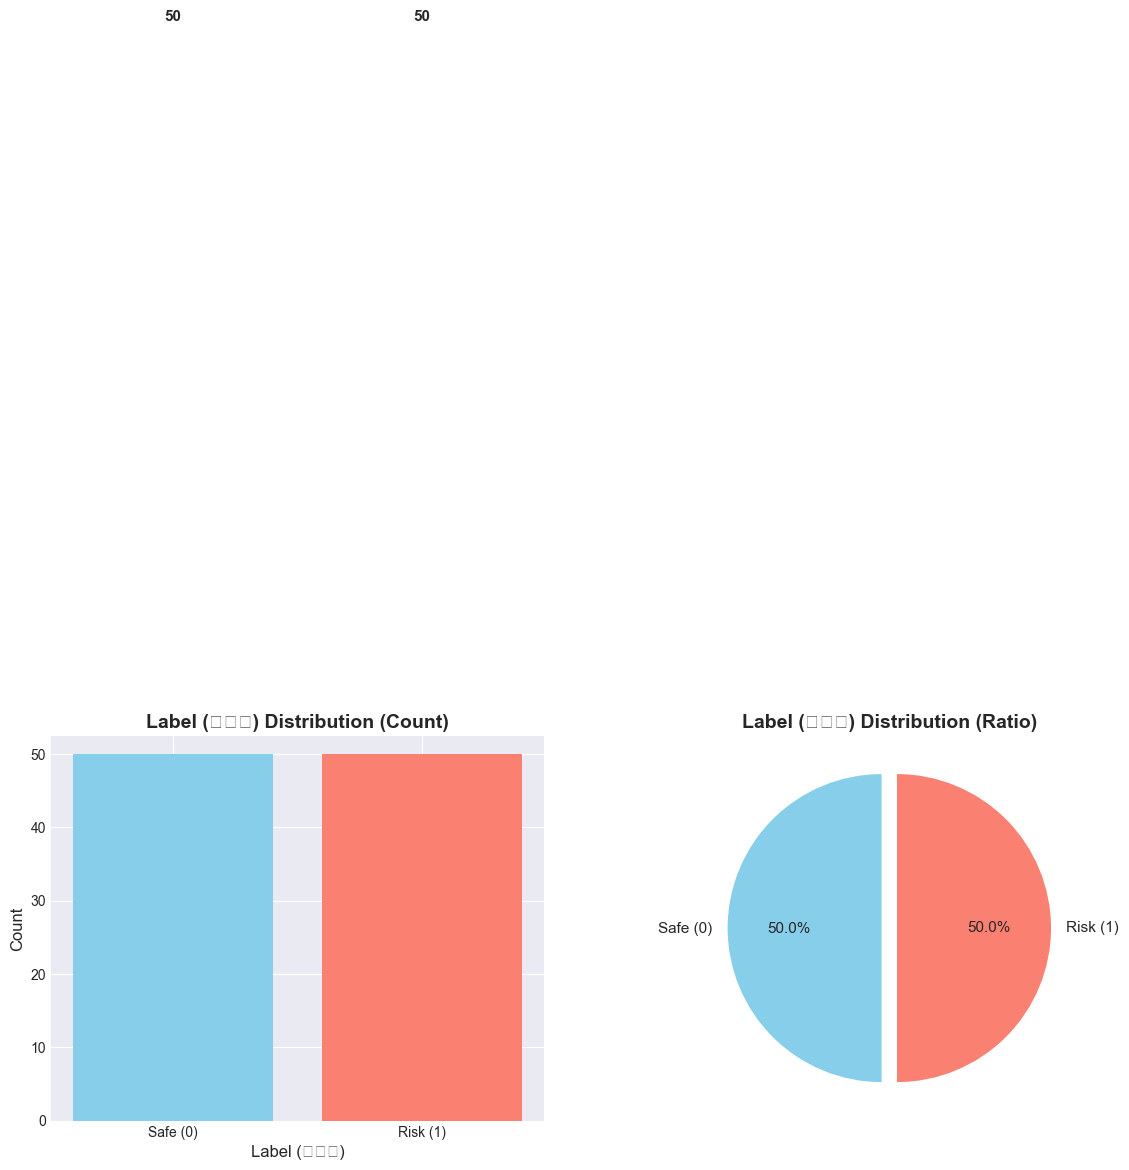

2025-11-10 22:06:09 [I] 
2. Feature Distributions...
2025-11-10 22:06:09 [I] 
2025-11-10 22:06:09 [I] Feature Distribution Statistics (Top 20)
2025-11-10 22:06:09 [I] ================================================================================
2025-11-10 22:06:09 [I] 
                        Feature Safe_Mean Risk_Mean     Diff  Safe_Std  Risk_Std
0       A1L_fail_rate (A1좌_실패율)    0.9933    0.9933   0.0000    0.0267    0.0348
1     A1L_mean_error (A1좌_평균오차)   43.3200   28.8800  14.4400  173.2063  142.9189
2      A1L_fast_fail (A1좌_조급실패)    0.9800    0.9800   0.0000    0.0800    0.1045
3            A1L_std (A1좌_표준편차)    0.0000    0.0000   0.0000    0.0000    0.0000
4       A1R_fail_rate (A1우_실패율)    1.0000    0.9911   0.0089    0.0000    0.0304
5     A1R_mean_error (A1우_평균오차)    0.0000   49.1000  49.1000    0.0000  173.3489
6      A1R_fast_fail (A1우_조급실패)    1.0000    0.9800   0.0200    0.0000    0.0800
7            A1R_std (A1우_표준편차)    0.0000    0.0000   0.0000    0.0000    0.000

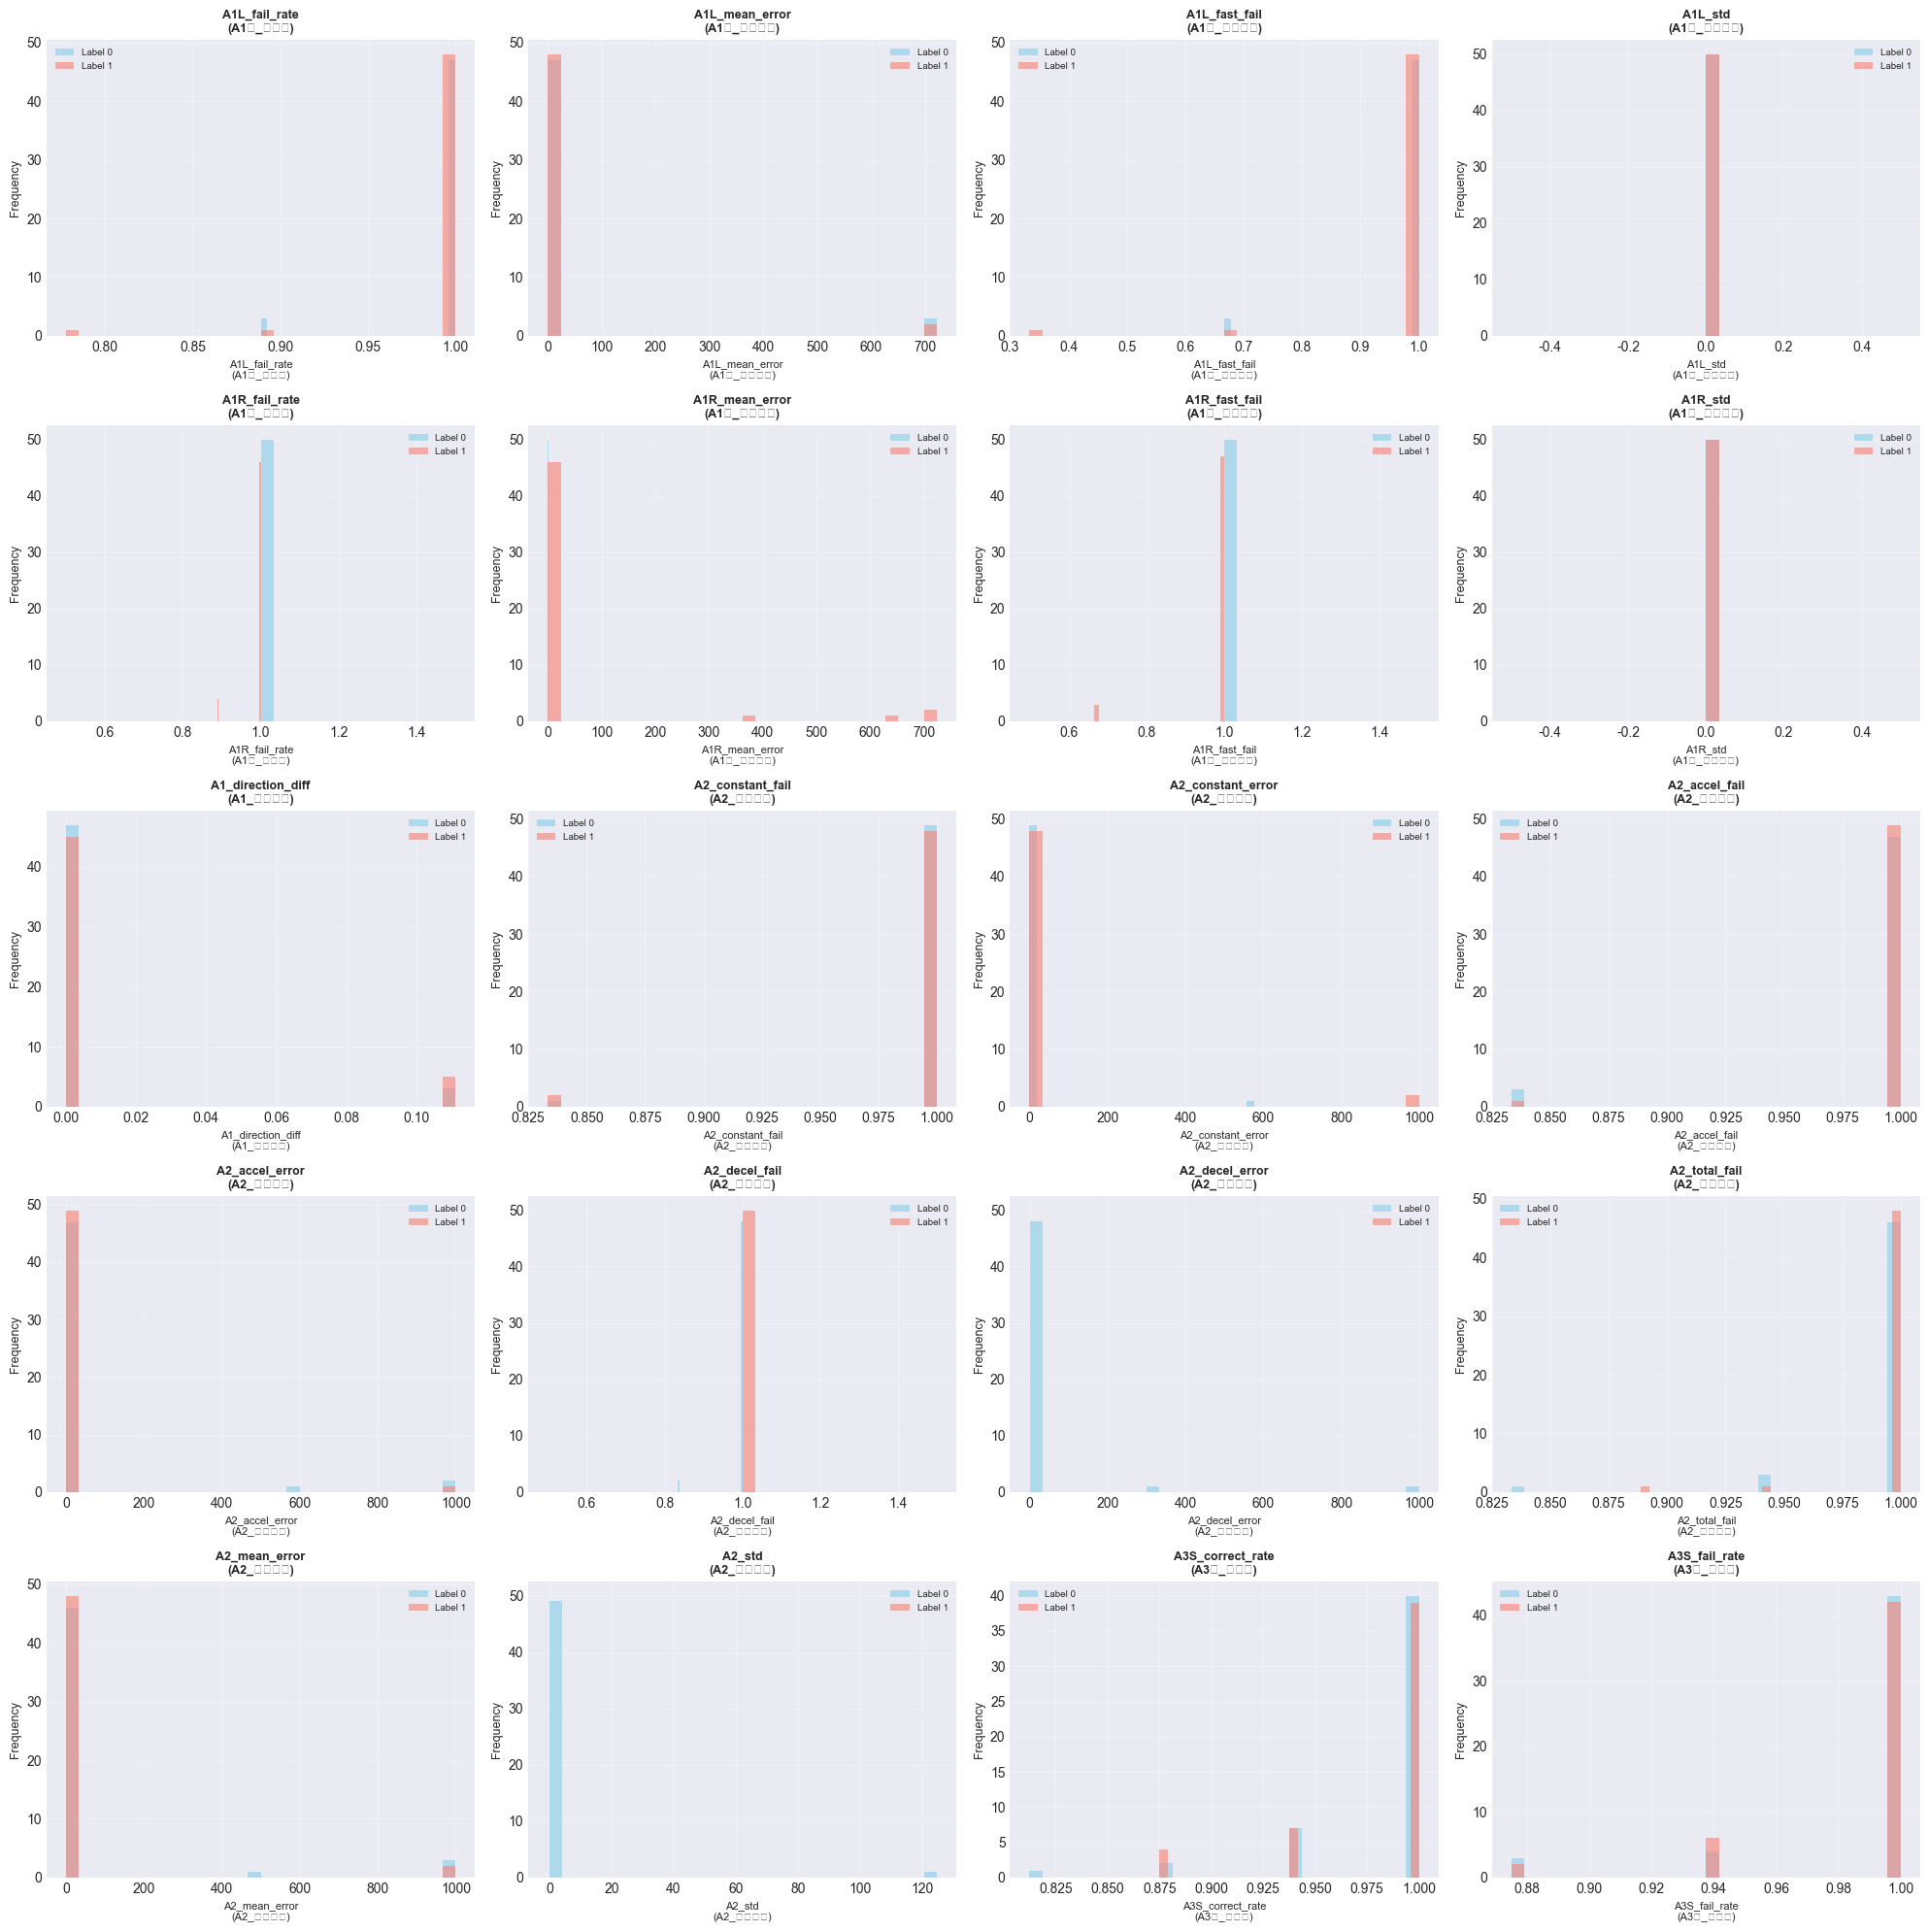

2025-11-10 22:06:19 [I] 
3. Correlation Analysis...
2025-11-10 22:06:19 [I] 
2025-11-10 22:06:19 [I] Correlation with Label - Correlation Matrix - Top 30 Features
2025-11-10 22:06:19 [I] ================================================================================
2025-11-10 22:06:19 [I] 
                             Feature Correlation Abs_Correlation
0       A4I_correct_rate (A4불일치_정답률)      0.2196          0.2196
1    A8_consistency_score (A8_일관성점수)      0.1995          0.1995
2     A8_consistency_norm (A8_일관성표준)      0.1995          0.1995
3          A1R_mean_error (A1우_평균오차)      0.1983          0.1983
4        A6_incorrect_count (A6_오답수)      0.1852          0.1852
5                A9_go_rt (A9_고반응시간)      0.1833          0.1833
6           A9_cond1_rt (A9_조건1반응시간)      0.1833          0.1833
7         A4_total_correct (A4_전체정답)      0.1797          0.1797
8            A2_decel_fail (A2_감속실패)      0.1429          0.1429
9   A3_valid_invalid_diff (A3_유무효차이)      0.1337         

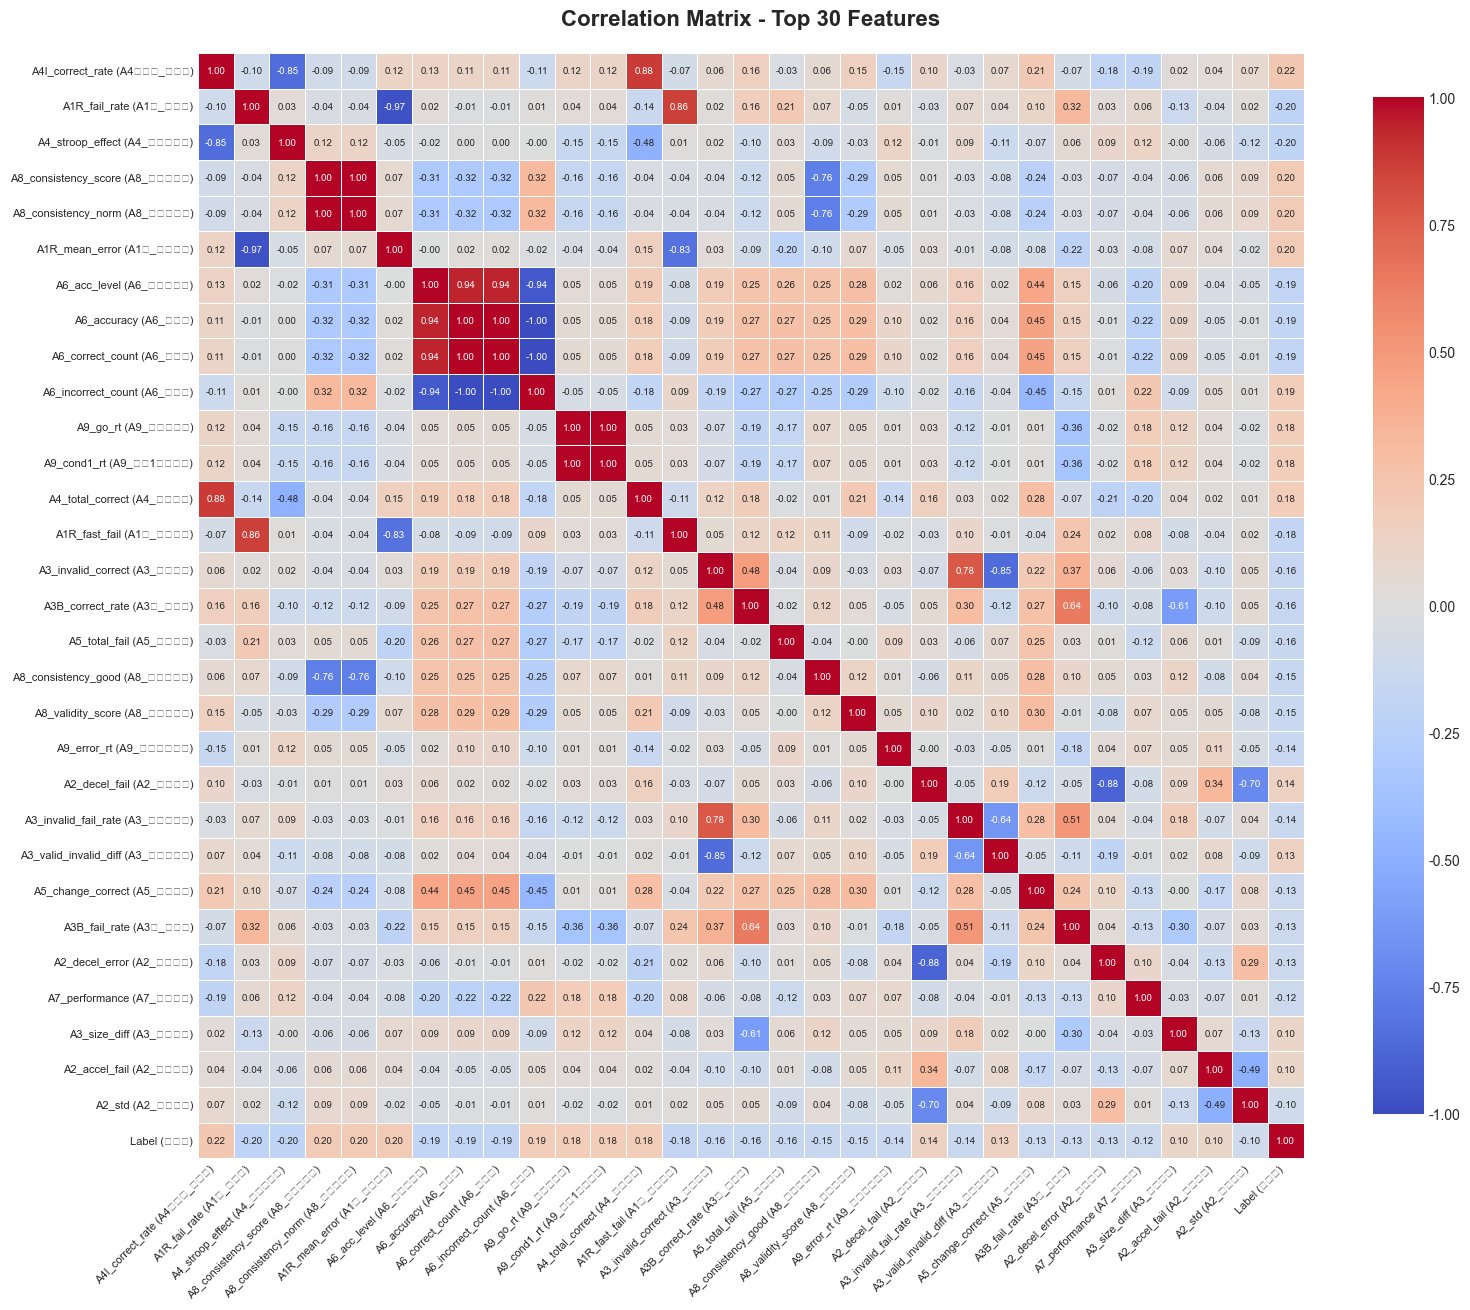

2025-11-10 22:06:24 [I] 
4. Preliminary Feature Importance...
2025-11-10 22:06:24 [I] 
2025-11-10 22:06:24 [I] Top 20 Feature Importance (Preliminary)
2025-11-10 22:06:24 [I] ================================================================================
2025-11-10 22:06:24 [I] 
    Rank                          Feature Abs_Correlation Importance_Score
0      1     A4I_correct_rate (A4불일치_정답률)          0.2196          100.00%
1      2          A1R_fail_rate (A1우_실패율)          0.2041           92.96%
2      3      A4_stroop_effect (A4_스트룹효과)          0.1998           90.99%
3      4  A8_consistency_score (A8_일관성점수)          0.1995           90.84%
4      5   A8_consistency_norm (A8_일관성표준)          0.1995           90.84%
5      6        A1R_mean_error (A1우_평균오차)          0.1983           90.31%
6      7          A6_acc_level (A6_정확도레벨)          0.1864           84.87%
7      8             A6_accuracy (A6_정확도)          0.1852           84.33%
8      9        A6_correct_count (A6_정답수)   

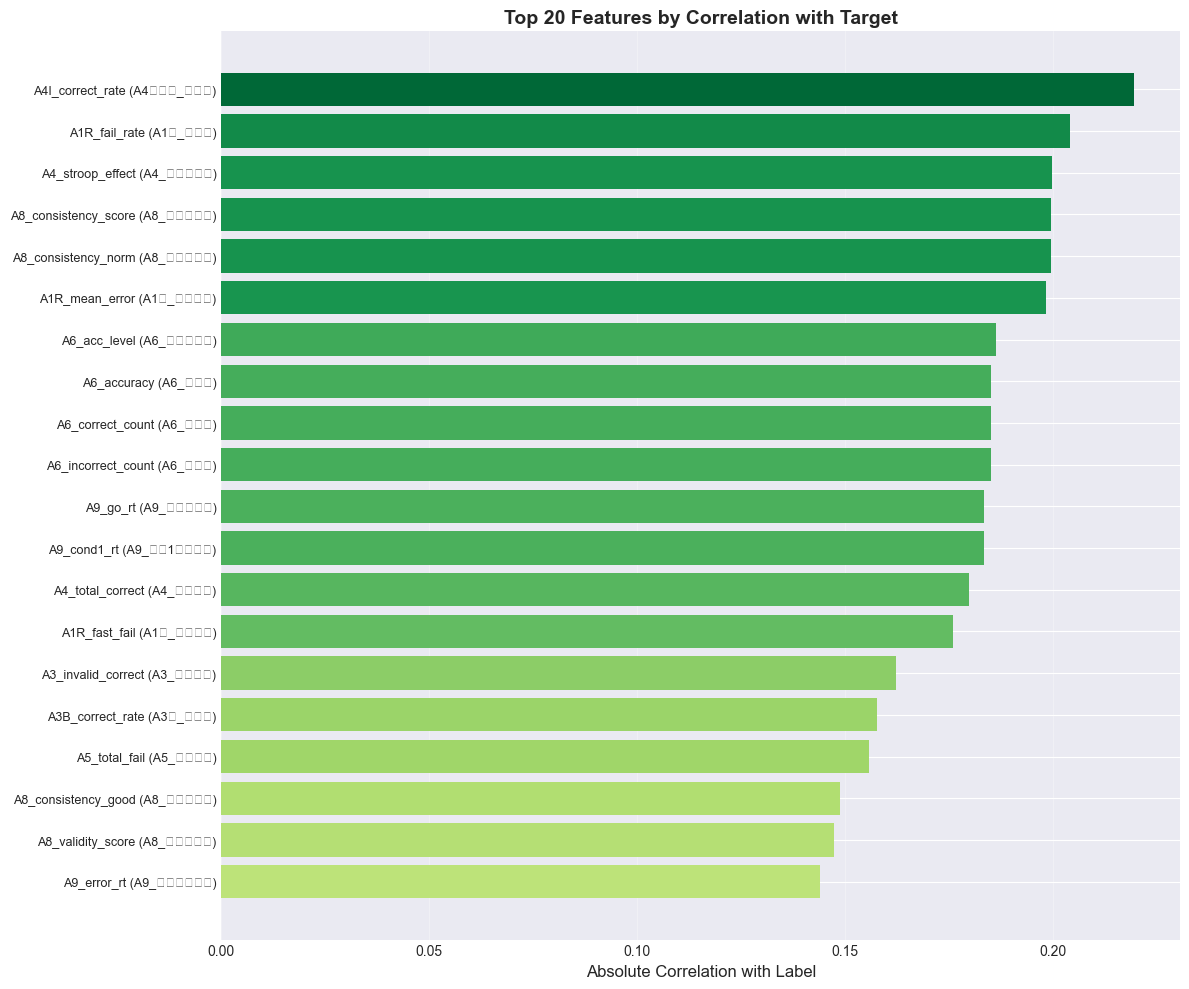

2025-11-10 22:06:25 [I] 
5. Test Group Analysis...
2025-11-10 22:06:25 [I] 
2025-11-10 22:06:25 [I] Test Group Summary Statistics
2025-11-10 22:06:25 [I] ================================================================================
2025-11-10 22:06:25 [I] 
  Group  Num_Features Safe_Avg Risk_Avg Avg_Diff  Max_Diff
0    A1             9   5.2556   9.1040   3.8484   49.1000
1    A2             9  18.3704  11.5430   6.8275   31.4800
2    A3            14  72.1140  93.5631  21.4491  150.1500
3    A4            10   0.5966   0.5972   0.0006    0.0115
4    A5             4   0.5817   0.5583   0.0233    0.0400
5    A6             4   4.3161   4.2239   0.0921    1.2400
6    A7             5   4.5680   4.5347   0.0333    0.2800
7    A8             8   1.1128   1.2265   0.1136    0.5200
8    A9            28   1.7471   1.5207   0.2264    1.3200

2025-11-10 22:06:28 [I]   ✓ Plot saved: D:\GoogleDrive\modeling\driver_aptitude\plots\05_test_group_analysis.png


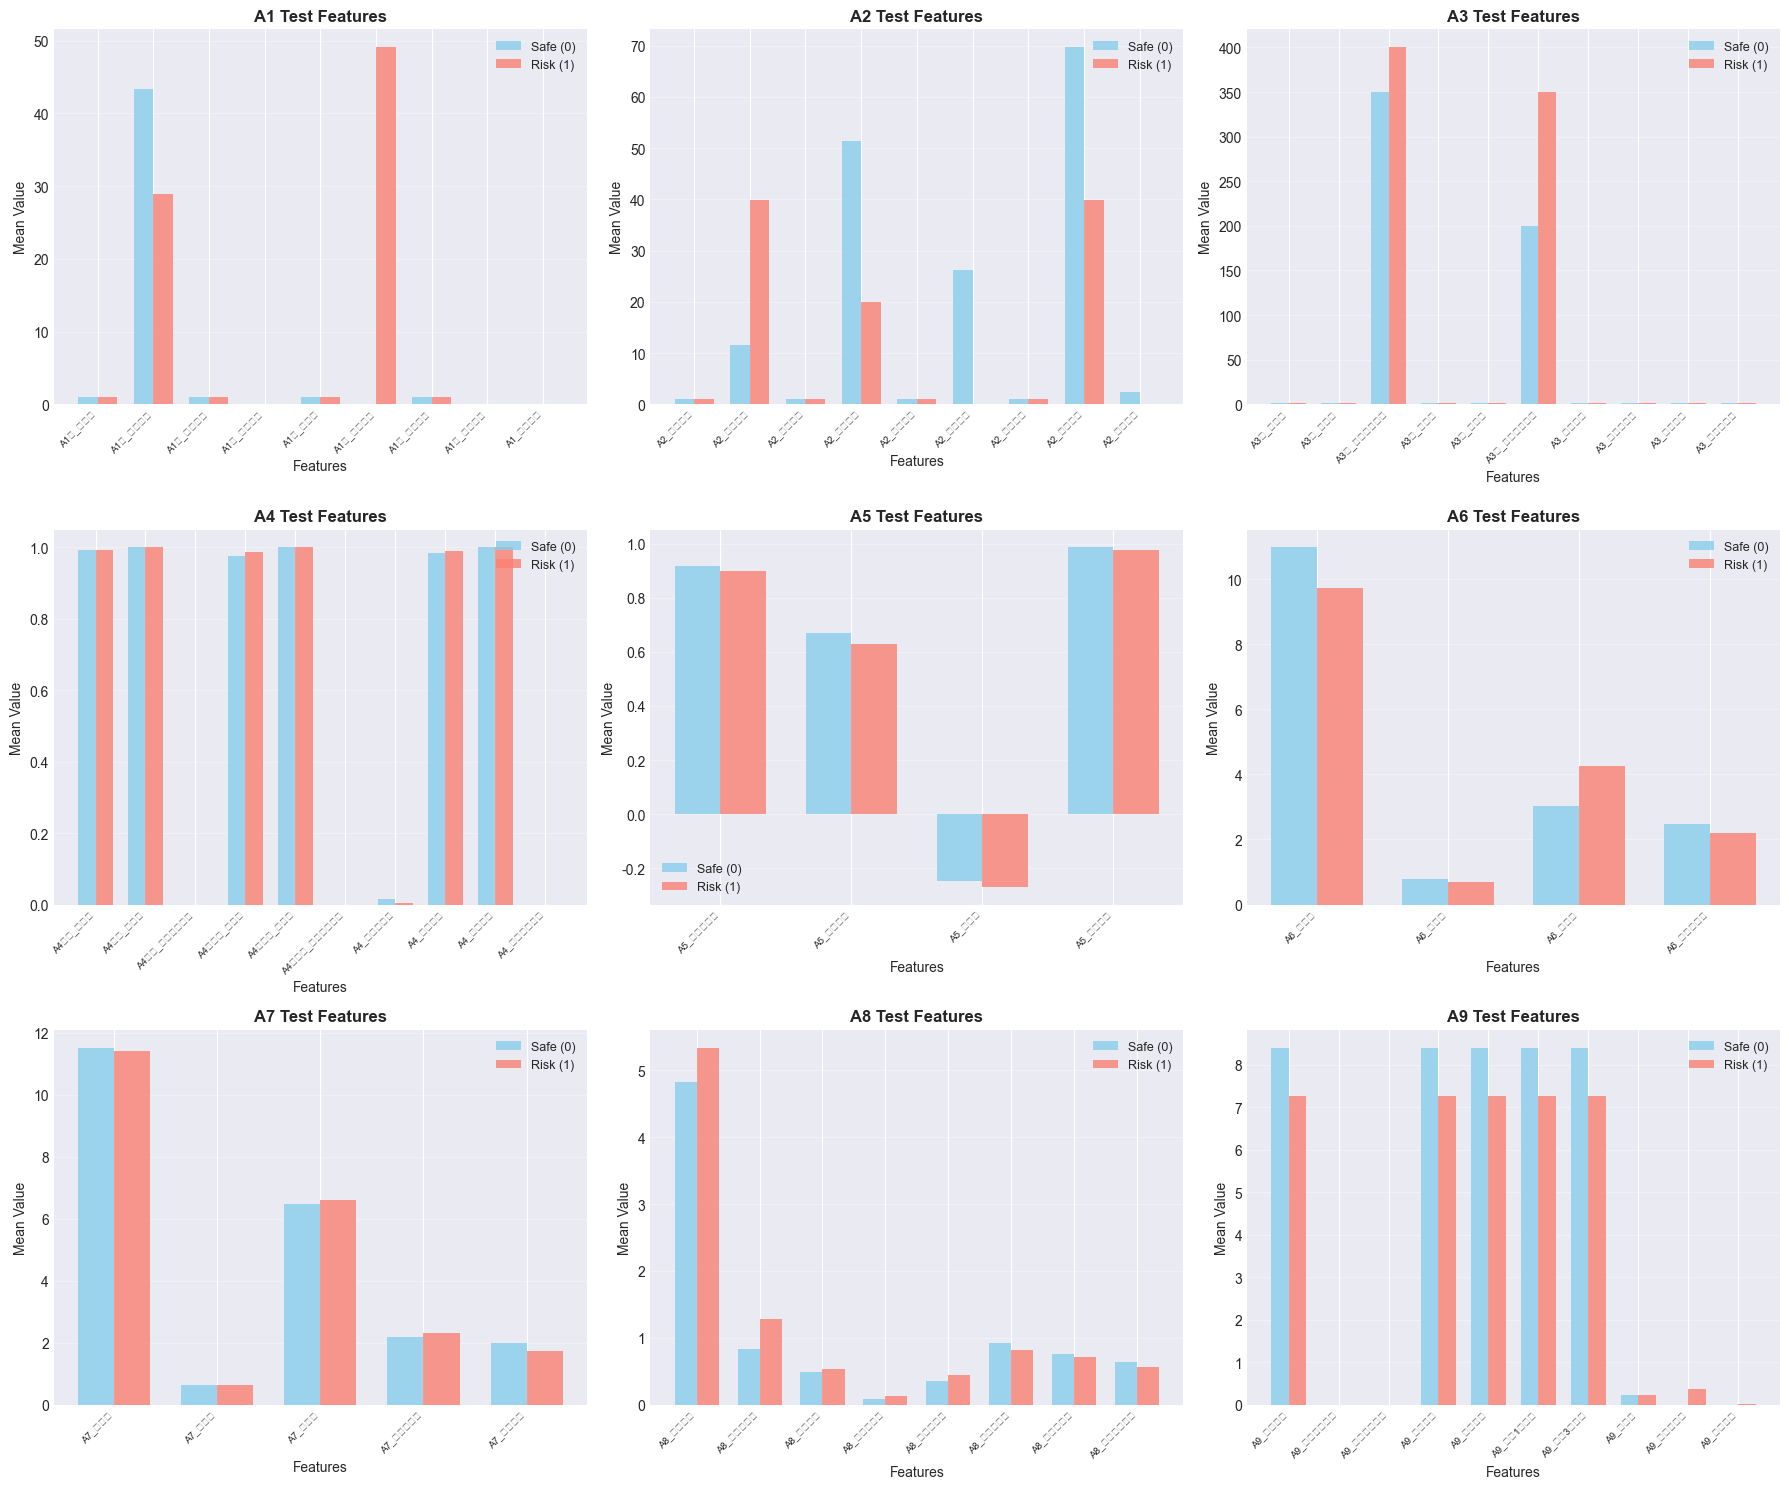

2025-11-10 22:06:29 [I] 
6. Boxplot Analysis...
2025-11-10 22:06:29 [I] 
2025-11-10 22:06:29 [I] Boxplot Statistics (Top 12 Features)
2025-11-10 22:06:29 [I] ================================================================================
2025-11-10 22:06:29 [I] 
                            Feature  Safe_Q1 Safe_Median  Safe_Q3 Risk_Q1 Risk_Median  Risk_Q3 Median_Diff
0      A4I_correct_rate (A4불일치_정답률)   0.9500      0.9750   1.0000  0.9750      1.0000   1.0000      0.0250
1           A1R_fail_rate (A1우_실패율)   1.0000      1.0000   1.0000  1.0000      1.0000   1.0000      0.0000
2       A4_stroop_effect (A4_스트룹효과)   0.0000      0.0000   0.0250  0.0000      0.0000   0.0000      0.0000
3   A8_consistency_score (A8_일관성점수)   0.0000      1.0000   1.0000  0.0000      1.0000   2.0000      0.0000
4    A8_consistency_norm (A8_일관성표준)   0.0000      0.1000   0.1000  0.0000      0.1000   0.2000      0.0000
5         A1R_mean_error (A1우_평균오차)   0.0000      0.0000   0.0000  0.0000      0.0000   0.0000

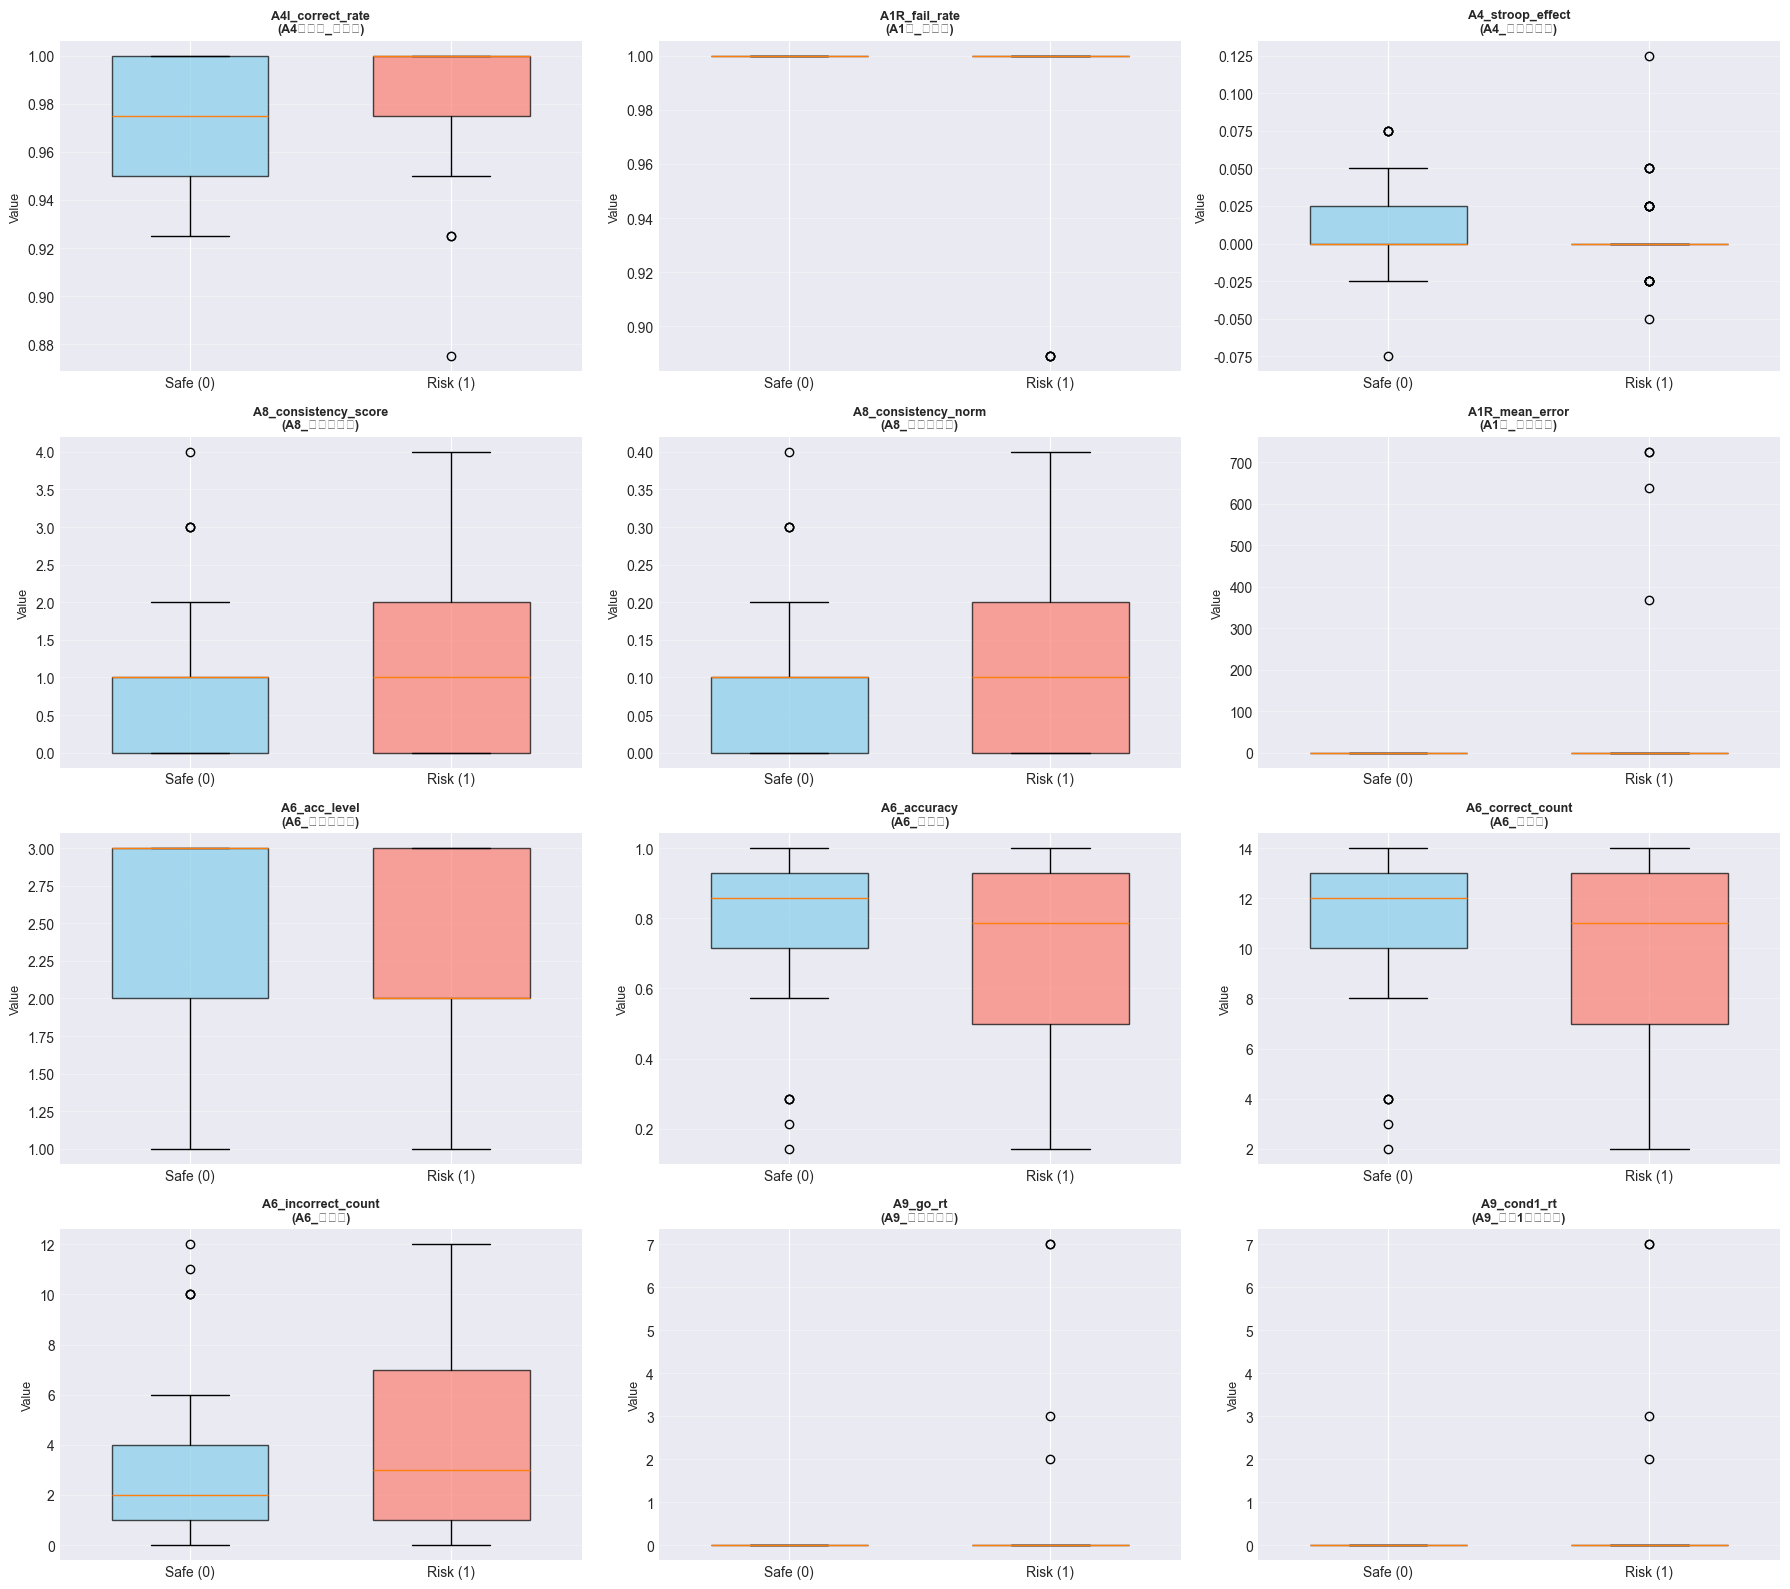

2025-11-10 22:06:33 [I] 
7. Correlation Matrix - A3...
2025-11-10 22:06:33 [I] 
2025-11-10 22:06:33 [I] Correlation with Label - Correlation Matrix - A3
2025-11-10 22:06:33 [I] ================================================================================
2025-11-10 22:06:33 [I] 
                             Feature Correlation Abs_Correlation
0   A3_valid_invalid_diff (A3_유무효차이)      0.1337          0.1337
1             A3_size_diff (A3_크기차이)      0.1033          0.1033
2           A3B_mean_rt (A3대_평균반응시간)      0.0959          0.0959
3             A3_mean_rt (A3_평균반응시간)      0.0500          0.0500
4           A3S_mean_rt (A3소_평균반응시간)      0.0280          0.0280
5            A3S_fail_rate (A3소_실패율)     -0.0000          0.0000
6      A3_valid_fail_rate (A3_유효실패율)     -0.0000          0.0000
7         A3S_correct_rate (A3소_정답률)     -0.0161          0.0161
8         A3_valid_correct (A3_유효정답)     -0.0419          0.0419
9            A3_total_fail (A3_전체실패)     -0.0693          0.0693
10

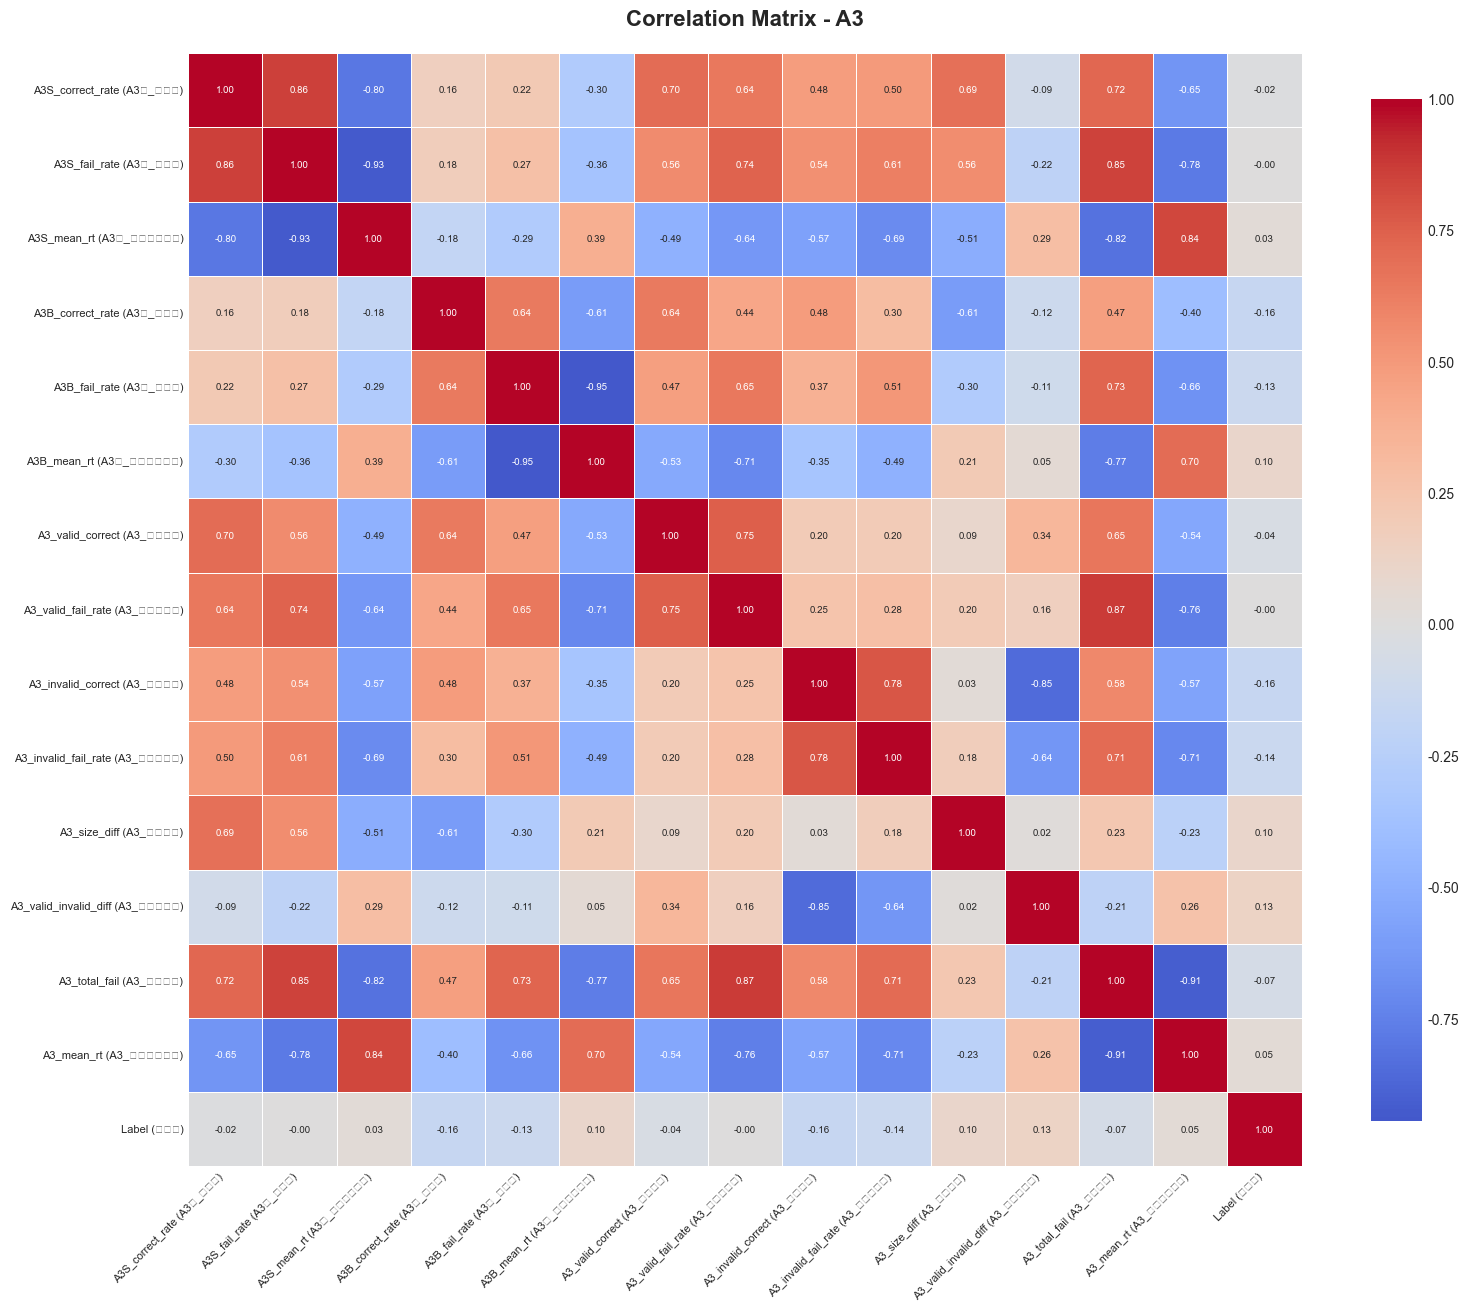

2025-11-10 22:06:35 [I] 
7. Correlation Matrix - A5...
2025-11-10 22:06:35 [I] 
2025-11-10 22:06:35 [I] Correlation with Label - Correlation Matrix - A5
2025-11-10 22:06:35 [I] ================================================================================
2025-11-10 22:06:35 [I] 
                           Feature Correlation Abs_Correlation
0  A5_no_change_correct (A5_무변화정답)     -0.0556          0.0556
1          A5_sensitivity (A5_민감도)     -0.0579          0.0579
2      A5_change_correct (A5_변화정답)     -0.1281          0.1281
3          A5_total_fail (A5_전체실패)     -0.1559          0.1559

2025-11-10 22:06:36 [I]   ✓ Plot saved: D:\GoogleDrive\modeling\driver_aptitude\plots\03_correlation_matrix_A5.png


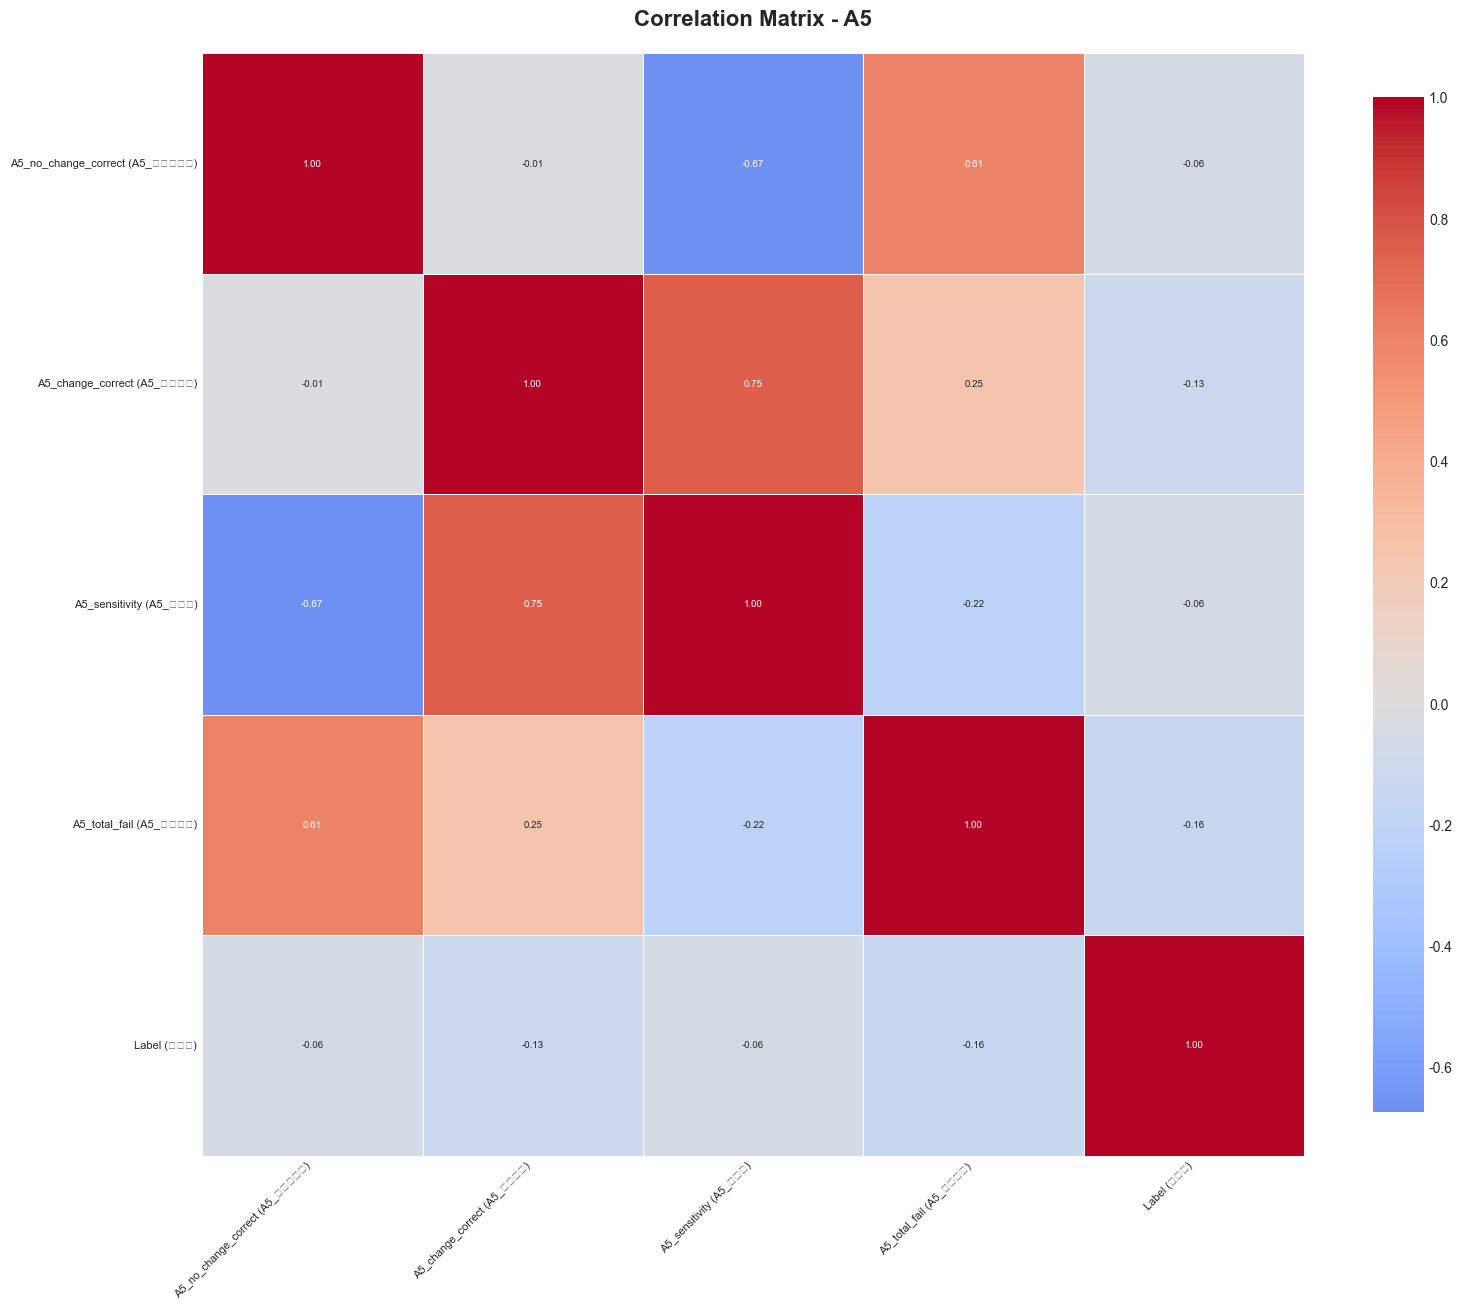

2025-11-10 22:06:36 [I] 
7. Correlation Matrix - A9...
2025-11-10 22:06:36 [I] 
2025-11-10 22:06:36 [I] Correlation with Label - Correlation Matrix - A9
2025-11-10 22:06:36 [I] ================================================================================
2025-11-10 22:06:36 [I] 
                            Feature Correlation Abs_Correlation
0               A9_go_rt (A9_고반응시간)      0.1833          0.1833
1          A9_cond1_rt (A9_조건1반응시간)      0.1833          0.1833
2          A9_cond3_acc (A9_조건3정확도)      0.1005          0.1005
3               A9_go_acc (A9_고정확도)      0.1005          0.1005
4          A9_cond1_acc (A9_조건1정확도)      0.1005          0.1005
5               A9_go_miss (A9_고누락)      0.0586          0.0586
6         A9_correct_rt (A9_정답반응시간)      0.0456          0.0456
7         A9_response_rate (A9_반응률)     -0.0000          0.0000
8              A9_accuracy (A9_정확도)     -0.0000          0.0000
9            A9_nogo_rt (A9_노고반응시간)     -0.0195          0.0195
10         A9

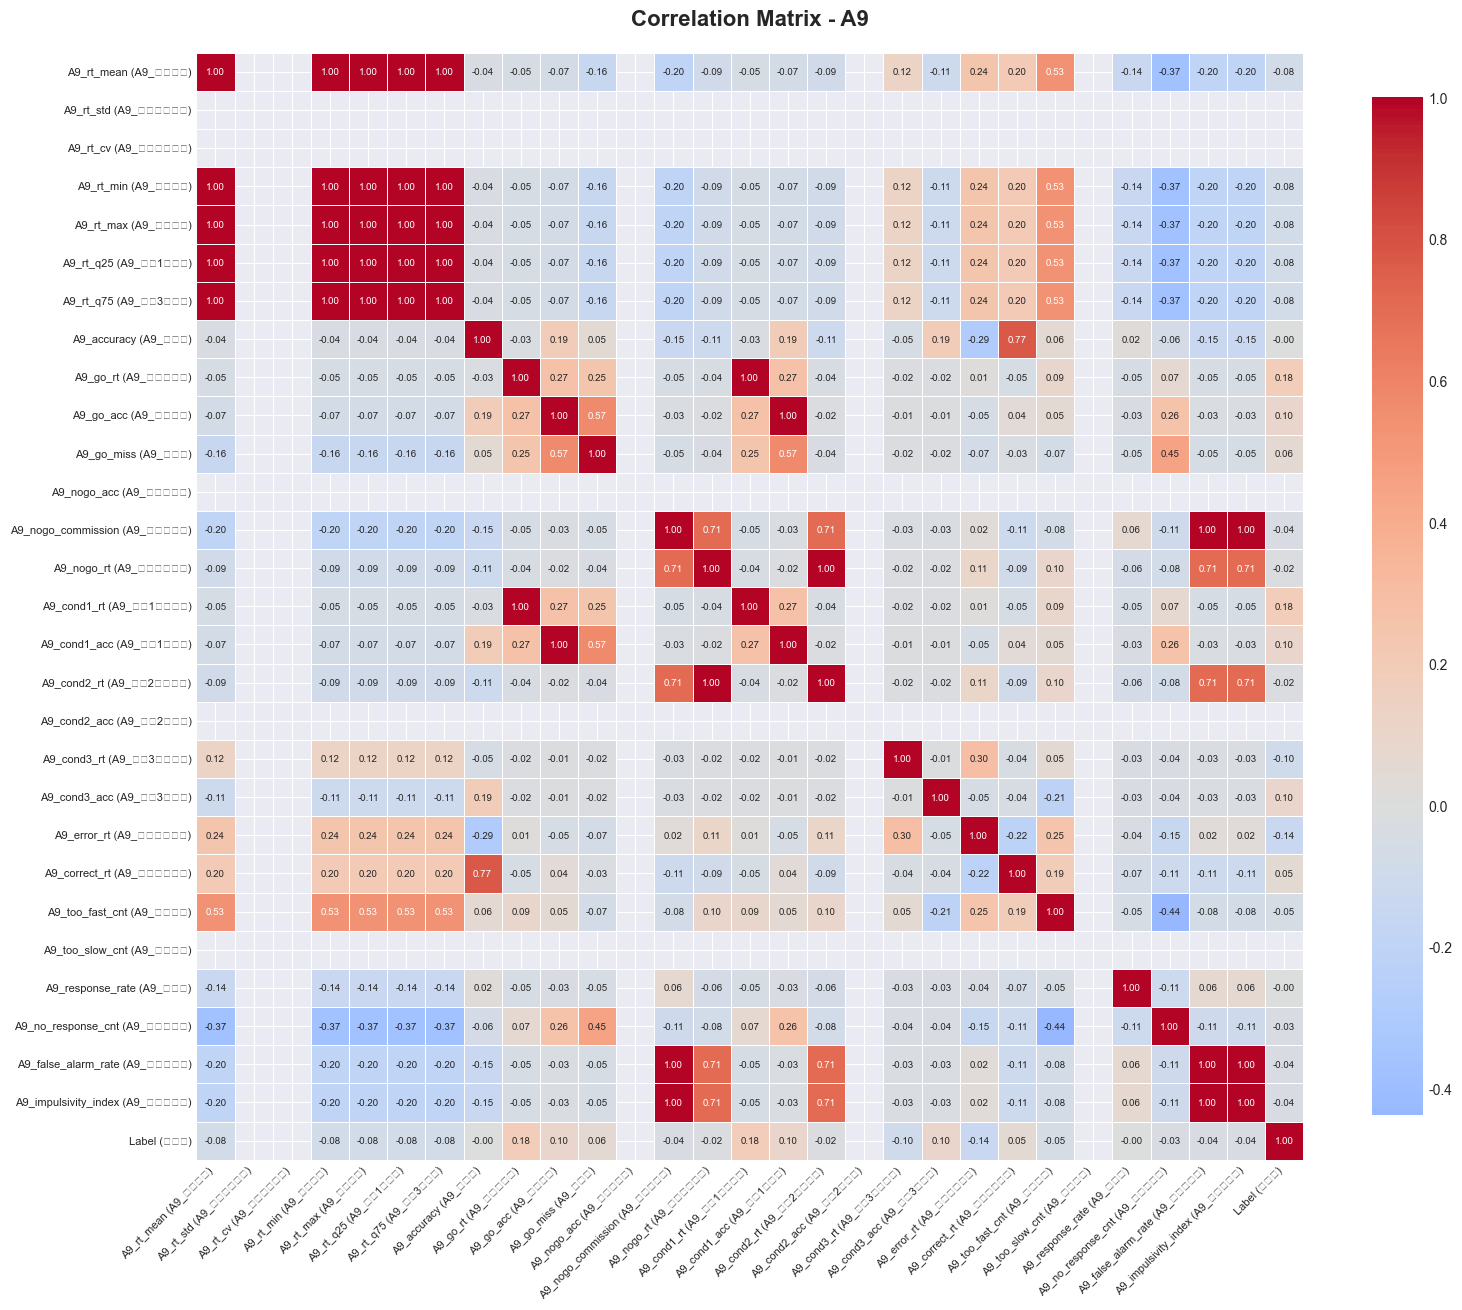

2025-11-10 22:06:39 [I] 
2025-11-10 22:06:39 [I] ✓ Full Analysis Report Generated
2025-11-10 22:06:39 [I]   Plots saved to: D:\GoogleDrive\modeling\driver_aptitude\plots
2025-11-10 22:06:39 [I] ================================================================================


In [14]:

"""
데이터 분석 및 시각화 파이프라인
Data Analysis and Visualization Pipeline
"""

# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# from pathlib import Path
# from typing import Optional, List, Dict, Tuple
# import warnings
# warnings.filterwarnings('ignore')


class DataAnalyzer:
    """운수종사자 적성검사 데이터 분석 및 시각화"""
    
    def __init__(self, config, data_loader, col_kr_dict=None):
        """
        Args:
            config: ProjectConfig 인스턴스
            data_loader: DataLoader 인스턴스
            col_kr_dict: 영문-한글 컬럼명 매핑 딕셔너리 (기본값: col_kr_dict_A)
        """
        self.config = config
        self.loader = data_loader
        self.col_kr_dict = col_kr_dict if col_kr_dict is not None else col_kr_dict_A
        self.plot_dir = Path(config.data.output_dir) / "plots"
        self.plot_dir.mkdir(parents=True, exist_ok=True)
        
        # 시각화 스타일 설정
        try:
            plt.style.use(config.visualization.style)
        except:
            plt.style.use('default')
        
        # 한글 폰트 설정 (matplotlib 기본 설정)
        plt.rcParams['axes.unicode_minus'] = False
    
    def _get_display_name(self, feature: str) -> str:
        """
        피처명을 영문(한글) 형식으로 변환
        
        Args:
            feature: 영문 피처명
            
        Returns:
            str: "영문(한글)" 형식의 표시명
        """
        if feature in self.col_kr_dict:
            return f"{feature}\n({self.col_kr_dict[feature]})"
        return feature
    
    def _save_plot(self, filename: str):
        """그래프 저장"""
        if self.config.visualization.save_plots:
            filepath = self.plot_dir / f"{filename}.{self.config.visualization.plot_format}"
            plt.savefig(filepath, dpi=self.config.visualization.dpi, bbox_inches='tight')
            logger.info(f"  ✓ Plot saved: {filepath}")
    
    def _log_dataframe(self, df: pd.DataFrame, title: str = ""):
        """
        DataFrame을 테이블 형태로 로그 출력
        
        Args:
            df: 출력할 DataFrame
            title: 테이블 제목
        """
        if title:
            logger.info(f"\n{'='*80}")
            logger.info(f"{title}")
            logger.info(f"{'='*80}")
        
        # DataFrame을 문자열로 변환하여 출력
        logger.info(f"\n{df.to_string()}\n")
    
    def plot_label_distribution(self, df: Optional[pd.DataFrame] = None):
        """
        레이블 분포 시각화
        
        Args:
            df: 분석할 데이터프레임 (None이면 전체 데이터 사용)
        """
        if df is None:
            df = self.loader.data
        
        target_col = self.config.data.target_col
        target_display = self._get_display_name(target_col).replace('\n', ' ')
        
        # 통계 DataFrame 생성
        label_counts = df[target_col].value_counts().sort_index()
        stats_df = pd.DataFrame({
            'Label': ['Safe (0)', 'Risk (1)'],
            'Count': label_counts.values,
            'Percentage': [f"{v/len(df)*100:.2f}%" for v in label_counts.values],
            'Ratio': [f"{label_counts[0]/label_counts[1]:.2f}:1", "-"]
        })
        
        self._log_dataframe(stats_df, f"{target_display} Distribution Statistics")
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # 카운트 플롯
        axes[0].bar(label_counts.index, label_counts.values, color=['skyblue', 'salmon'])
        axes[0].set_xlabel(target_display, fontsize=12)
        axes[0].set_ylabel('Count', fontsize=12)
        axes[0].set_title(f'{target_display} Distribution (Count)', fontsize=14, fontweight='bold')
        axes[0].set_xticks([0, 1])
        axes[0].set_xticklabels(['Safe (0)', 'Risk (1)'])
        
        # 텍스트 추가
        for i, v in enumerate(label_counts.values):
            axes[0].text(i, v + 100, str(v), ha='center', fontsize=11, fontweight='bold')
        
        # 비율 파이 차트
        colors = ['skyblue', 'salmon']
        explode = (0.05, 0.05)
        axes[1].pie(label_counts.values, labels=['Safe (0)', 'Risk (1)'], 
                   autopct='%1.1f%%', colors=colors, explode=explode,
                   startangle=90, textprops={'fontsize': 11})
        axes[1].set_title(f'{target_display} Distribution (Ratio)', fontsize=14, fontweight='bold')
        
        plt.tight_layout()
        self._save_plot('01_label_distribution')
        plt.show()
    
    def plot_feature_distributions(self, 
                                   features: Optional[List[str]] = None,
                                   max_features: int = 20):
        """
        피처 분포 시각화
        
        Args:
            features: 시각화할 피처 리스트 (None이면 상위 max_features개 사용)
            max_features: 최대 피처 수
        """
        df = self.loader.data
        target_col = self.config.data.target_col
        
        if features is None:
            features = self.loader.get_feature_names()[:max_features]
        
        # 각 피처별 통계 DataFrame 생성
        stats_list = []
        for feature in features:
            safe_data = df[df[target_col] == 0][feature]
            risk_data = df[df[target_col] == 1][feature]
            
            stats_list.append({
                'Feature': f"{feature} ({self.col_kr_dict.get(feature, '')})",
                'Safe_Mean': f"{safe_data.mean():.4f}",
                'Risk_Mean': f"{risk_data.mean():.4f}",
                'Diff': f"{abs(safe_data.mean() - risk_data.mean()):.4f}",
                'Safe_Std': f"{safe_data.std():.4f}",
                'Risk_Std': f"{risk_data.std():.4f}"
            })
        
        stats_df = pd.DataFrame(stats_list)
        self._log_dataframe(stats_df, f"Feature Distribution Statistics (Top {len(features)})")
        
        n_features = len(features)
        n_cols = 4
        n_rows = (n_features + n_cols - 1) // n_cols
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows*4))
        axes = axes.flatten()
        
        for idx, feature in enumerate(features):
            ax = axes[idx]
            display_name = self._get_display_name(feature)
            
            # 각 Label별 분포
            for label in [0, 1]:
                data = df[df[target_col] == label][feature]
                ax.hist(data, bins=30, alpha=0.6, 
                       label=f'Label {label}', 
                       color='skyblue' if label == 0 else 'salmon')
            
            ax.set_xlabel(display_name, fontsize=8)
            ax.set_ylabel('Frequency', fontsize=9)
            ax.set_title(display_name, fontsize=9, fontweight='bold')
            ax.legend(fontsize=7)
            ax.grid(True, alpha=0.3)
        
        # 빈 서브플롯 제거
        for idx in range(n_features, len(axes)):
            fig.delaxes(axes[idx])
        
        plt.tight_layout()
        self._save_plot('02_feature_distributions')
        plt.show()
    
    def plot_correlation_matrix(self, 
                                feature_group: Optional[str] = None,
                                top_n: int = 30):
        """
        상관관계 행렬 히트맵
        
        Args:
            feature_group: 분석할 검사 그룹 (None이면 전체, "A1", "A2" 등)
            top_n: 전체 분석 시 상위 N개 피처
        """
        df = self.loader.data
        target_col = self.config.data.target_col
        
        # 피처 선택
        if feature_group is not None:
            if feature_group in self.config.data.feature_groups:
                features = self.config.data.feature_groups[feature_group]
                title = f'Correlation Matrix - {feature_group}'
            else:
                logger.info(f"Warning: Unknown feature group '{feature_group}'")
                return
        else:
            # 타겟과의 상관계수 기준 상위 N개
            numeric_features = df.select_dtypes(include=[np.number]).columns
            numeric_features = [f for f in numeric_features if f != target_col]
            
            correlations = df[numeric_features].corrwith(df[target_col]).abs()
            top_features = correlations.nlargest(top_n).index.tolist()
            features = top_features
            title = f'Correlation Matrix - Top {top_n} Features'
        
        # 상관관계 계산
        corr_matrix = df[features + [target_col]].corr()
        
        # Label과의 상관관계 DataFrame 출력
        label_corr = corr_matrix[target_col].drop(target_col).sort_values(ascending=False)
        corr_df = pd.DataFrame({
            'Feature': [f"{f} ({self.col_kr_dict.get(f, '')})" for f in label_corr.index],
            'Correlation': [f"{v:.4f}" for v in label_corr.values],
            'Abs_Correlation': [f"{abs(v):.4f}" for v in label_corr.values]
        })
        
        self._log_dataframe(corr_df, f"Correlation with Label - {title}")
        
        # 한글 레이블 생성
        display_labels = [self._get_display_name(f).replace('\n', ' ') for f in features + [target_col]]
        corr_matrix.index = display_labels
        corr_matrix.columns = display_labels
        
        # 히트맵 그리기
        fig, ax = plt.subplots(figsize=(16, 14))
        sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, square=True, linewidths=0.5, 
                cbar_kws={"shrink": 0.8}, ax=ax, annot_kws={'size': 7})
        
        ax.set_title(title, fontsize=16, fontweight='bold', pad=20)
        plt.xticks(rotation=45, ha='right', fontsize=8)
        plt.yticks(rotation=0, fontsize=8)
        
        plt.tight_layout()
        suffix = feature_group if feature_group else 'top'
        self._save_plot(f'03_correlation_matrix_{suffix}')
        plt.show()
    
    def plot_feature_importance_preliminary(self, top_n: int = 20):
        """
        타겟과의 상관계수 기반 사전 피처 중요도
        
        Args:
            top_n: 상위 N개 피처
        """
        df = self.loader.data
        target_col = self.config.data.target_col
        
        # 수치형 피처만 선택
        numeric_features = df.select_dtypes(include=[np.number]).columns
        numeric_features = [f for f in numeric_features if f != target_col]
        
        # 타겟과의 상관계수 계산
        correlations = df[numeric_features].corrwith(df[target_col]).abs()
        top_features = correlations.nlargest(top_n).sort_values(ascending=False)
        
        # 중요도 DataFrame 생성
        importance_df = pd.DataFrame({
            'Rank': range(1, len(top_features) + 1),
            'Feature': [f"{f} ({self.col_kr_dict.get(f, '')})" for f in top_features.index],
            'Abs_Correlation': [f"{v:.4f}" for v in top_features.values],
            'Importance_Score': [f"{v/top_features.values[0]*100:.2f}%" for v in top_features.values]
        })
        
        self._log_dataframe(importance_df, f"Top {top_n} Feature Importance (Preliminary)")
        
        # 한글 레이블 생성
        top_features_sorted = top_features.sort_values(ascending=True)
        display_labels = [self._get_display_name(f).replace('\n', ' ') for f in top_features_sorted.index]
        
        # 시각화
        fig, ax = plt.subplots(figsize=(12, 10))
        colors = plt.cm.RdYlGn(top_features_sorted.values / top_features_sorted.values.max())
        ax.barh(range(len(top_features_sorted)), top_features_sorted.values, color=colors)
        ax.set_yticks(range(len(top_features_sorted)))
        ax.set_yticklabels(display_labels, fontsize=9)
        ax.set_xlabel('Absolute Correlation with Label', fontsize=12)
        ax.set_title(f'Top {top_n} Features by Correlation with Target', 
                    fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='x')
        
        plt.tight_layout()
        self._save_plot('04_feature_importance_preliminary')
        plt.show()
    
    def plot_test_group_analysis(self):
        """
        A검사 그룹별 분석
        """
        df = self.loader.data
        target_col = self.config.data.target_col
        
        # 그룹별 통계 수집
        group_stats_list = []
        for group_name, features in self.config.data.feature_groups.items():
            safe_means = df[df[target_col] == 0][features].mean()
            risk_means = df[df[target_col] == 1][features].mean()
            
            group_stats_list.append({
                'Group': group_name,
                'Num_Features': len(features),
                'Safe_Avg': f"{safe_means.mean():.4f}",
                'Risk_Avg': f"{risk_means.mean():.4f}",
                'Avg_Diff': f"{abs(safe_means.mean() - risk_means.mean()):.4f}",
                'Max_Diff': f"{abs(safe_means - risk_means).max():.4f}"
            })
        
        group_stats_df = pd.DataFrame(group_stats_list)
        self._log_dataframe(group_stats_df, "Test Group Summary Statistics")
        
        n_groups = len(self.config.data.feature_groups)
        n_cols = 3
        n_rows = (n_groups + n_cols - 1) // n_cols
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows*5))
        axes = axes.flatten()
        
        for idx, (group_name, features) in enumerate(self.config.data.feature_groups.items()):
            ax = axes[idx]
            
            # 각 검사 그룹의 평균값 비교
            safe_means = df[df[target_col] == 0][features].mean()
            risk_means = df[df[target_col] == 1][features].mean()
            
            x = np.arange(min(len(features), 10))  # 최대 10개 피처만 표시
            width = 0.35
            
            display_features = features[:10]
            safe_values = safe_means[display_features].values
            risk_values = risk_means[display_features].values
            
            ax.bar(x - width/2, safe_values, width, label='Safe (0)', 
                  color='skyblue', alpha=0.8)
            ax.bar(x + width/2, risk_values, width, label='Risk (1)', 
                  color='salmon', alpha=0.8)
            
            ax.set_xlabel('Features', fontsize=10)
            ax.set_ylabel('Mean Value', fontsize=10)
            ax.set_title(f'{group_name} Test Features', fontsize=12, fontweight='bold')
            
            # 한글 레이블 적용
            display_labels = [self.col_kr_dict.get(f, f.split('_')[-1]) 
                            for f in display_features]
            ax.set_xticks(x)
            ax.set_xticklabels(display_labels, rotation=45, ha='right', fontsize=7)
            ax.legend(fontsize=9)
            ax.grid(True, alpha=0.3, axis='y')
        
        # 빈 서브플롯 제거
        for idx in range(n_groups, len(axes)):
            fig.delaxes(axes[idx])
        
        plt.tight_layout()
        self._save_plot('05_test_group_analysis')
        plt.show()
    
    def plot_boxplots_by_label(self, features: Optional[List[str]] = None, max_features: int = 12):
        """
        레이블별 박스플롯
        
        Args:
            features: 시각화할 피처 (None이면 상위 중요 피처)
            max_features: 최대 피처 수
        """
        df = self.loader.data
        target_col = self.config.data.target_col
        
        if features is None:
            # 타겟과 상관관계 높은 피처 선택
            numeric_features = df.select_dtypes(include=[np.number]).columns
            numeric_features = [f for f in numeric_features if f != target_col]
            correlations = df[numeric_features].corrwith(df[target_col]).abs()
            features = correlations.nlargest(max_features).index.tolist()
        
        # 박스플롯 통계 DataFrame 생성
        boxplot_stats = []
        for feature in features:
            safe_data = df[df[target_col] == 0][feature]
            risk_data = df[df[target_col] == 1][feature]
            
            boxplot_stats.append({
                'Feature': f"{feature} ({self.col_kr_dict.get(feature, '')})",
                'Safe_Q1': f"{safe_data.quantile(0.25):.4f}",
                'Safe_Median': f"{safe_data.median():.4f}",
                'Safe_Q3': f"{safe_data.quantile(0.75):.4f}",
                'Risk_Q1': f"{risk_data.quantile(0.25):.4f}",
                'Risk_Median': f"{risk_data.median():.4f}",
                'Risk_Q3': f"{risk_data.quantile(0.75):.4f}",
                'Median_Diff': f"{abs(safe_data.median() - risk_data.median()):.4f}"
            })
        
        boxplot_df = pd.DataFrame(boxplot_stats)
        self._log_dataframe(boxplot_df, f"Boxplot Statistics (Top {len(features)} Features)")
        
        n_features = len(features)
        n_cols = 3
        n_rows = (n_features + n_cols - 1) // n_cols
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows*4))
        axes = axes.flatten()
        
        for idx, feature in enumerate(features):
            ax = axes[idx]
            display_name = self._get_display_name(feature)
            
            data_to_plot = [df[df[target_col] == 0][feature].dropna(),
                           df[df[target_col] == 1][feature].dropna()]
            
            bp = ax.boxplot(data_to_plot, labels=['Safe (0)', 'Risk (1)'],
                           patch_artist=True, widths=0.6)
            
            # 색상 설정
            colors = ['skyblue', 'salmon']
            for patch, color in zip(bp['boxes'], colors):
                patch.set_facecolor(color)
                patch.set_alpha(0.7)
            
            ax.set_ylabel('Value', fontsize=9)
            ax.set_title(display_name, fontsize=9, fontweight='bold')
            ax.grid(True, alpha=0.3, axis='y')
        
        # 빈 서브플롯 제거
        for idx in range(n_features, len(axes)):
            fig.delaxes(axes[idx])
        
        plt.tight_layout()
        self._save_plot('06_boxplots_by_label')
        plt.show()
    
    def generate_full_report(self):
        """
        전체 분석 리포트 생성
        """
        logger.info("\n" + "="*80)
        logger.info("Generating Full Analysis Report")
        logger.info("="*80 + "\n")
        
        logger.info("1. Label Distribution Analysis...")
        self.plot_label_distribution()
        
        logger.info("\n2. Feature Distributions...")
        self.plot_feature_distributions(max_features=20)
        
        logger.info("\n3. Correlation Analysis...")
        self.plot_correlation_matrix(top_n=30)
        
        logger.info("\n4. Preliminary Feature Importance...")
        self.plot_feature_importance_preliminary(top_n=20)
        
        logger.info("\n5. Test Group Analysis...")
        self.plot_test_group_analysis()
        
        logger.info("\n6. Boxplot Analysis...")
        self.plot_boxplots_by_label(max_features=12)
        
        # 그룹별 상관관계 (주요 검사만)
        for group in ['A3', 'A5', 'A9']:
            logger.info(f"\n7. Correlation Matrix - {group}...")
            self.plot_correlation_matrix(feature_group=group)
        
        logger.info("\n" + "="*80)
        logger.info("✓ Full Analysis Report Generated")
        logger.info(f"  Plots saved to: {self.plot_dir}")
        logger.info("="*80)


def test_data_analyzer():
    # 테스트 코드   
    # 전역 설정 인스턴스
    #config = ProjectConfig()
    
    # 데이터 로드
    #loader = DataLoader(config)
    loader.load_json_data()
    loader.preprocess_data()
    loader.split_data()
    
    # 분석기 생성
    analyzer = DataAnalyzer(config, loader)
    
    # 전체 리포트 생성
    analyzer.generate_full_report()
    return analyzer
        
analyzer = test_data_analyzer()

2025-11-10 22:06:39 [I] 
2025-11-10 22:06:39 [I] Training LIGHTGBM Model
2025-11-10 22:06:39 [I] ============================================================
2025-11-10 22:06:39 [I]   Train samples: 80
2025-11-10 22:06:39 [I]   Val samples: 10
2025-11-10 22:06:39 [I]   Features: 91
2025-11-10 22:06:39 [I]   Scale pos weight: 1.00
2025-11-10 22:06:39 [I] 
  Training LightGBM...
2025-11-10 22:06:40 [W] No model to save checkpoint
2025-11-10 22:06:40 [W] No model to save checkpoint
2025-11-10 22:06:40 [I]   Best iteration: 1
2025-11-10 22:06:40 [I]   Best score: 0.6000
2025-11-10 22:06:40 [I] ✓ Checkpoint saved: D:\GoogleDrive\modeling\driver_aptitude\models\lightgbm_last_20251110_220640.pkl
2025-11-10 22:06:40 [I]   - Type: last
2025-11-10 22:06:40 [I]   - Iteration: 0
2025-11-10 22:06:40 [I]   - Score: 0.6000
2025-11-10 22:06:40 [I]   - Best Score: 0.6000
2025-11-10 22:06:40 [I] 
✓ Model training completed
2025-11-10 22:06:40 [I]   Total training duration: 0.05s


Training until validation scores don't improve for 50 rounds
[50]	train's auc: 0.814063	val's auc: 0.48
Early stopping, best iteration is:
[1]	train's auc: 0.6375	val's auc: 0.6

Evaluating on Test Set

Prediction distribution: {np.int64(0): np.int64(6), np.int64(1): np.int64(4)}
True label distribution: {np.int64(0): np.int64(5), np.int64(1): np.int64(5)}

Metrics:
  Accuracy:  0.5000
  Precision: 0.5000
  Recall:    0.4000
  F1-Score:  0.4444
  AUC:       0.5000

Confusion Matrix:
  TN:     3  FP:     2
  FN:     3  TP:     2

Classification Report:
              precision    recall  f1-score   support

        Safe       0.50      0.60      0.55         5
        Risk       0.50      0.40      0.44         5

    accuracy                           0.50        10
   macro avg       0.50      0.50      0.49        10
weighted avg       0.50      0.50      0.49        10



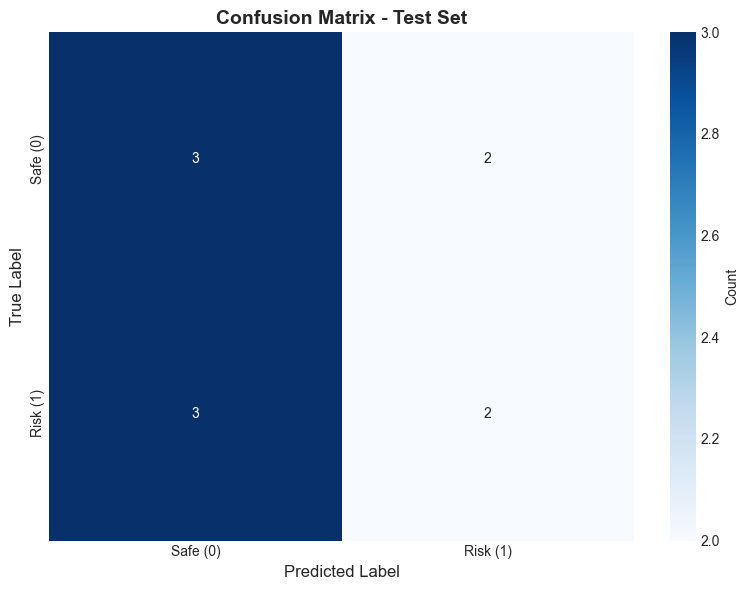

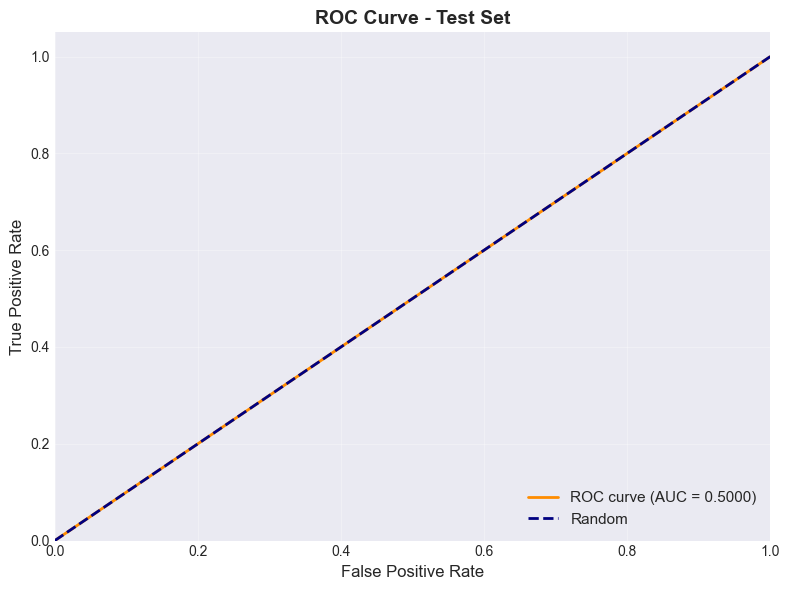

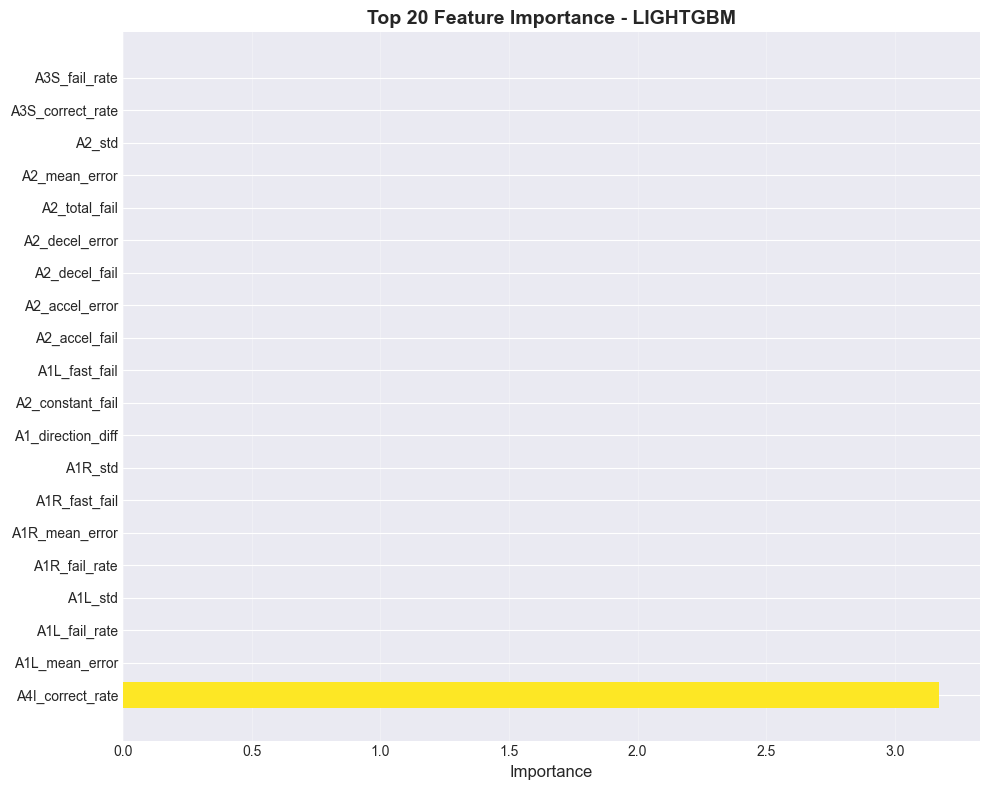


Top 20 Feature Importance
A4I_correct_rate              :       3.17
A1L_mean_error                :       0.00
A1L_fail_rate                 :       0.00
A1L_std                       :       0.00
A1R_fail_rate                 :       0.00
A1R_mean_error                :       0.00
A1R_fast_fail                 :       0.00
A1R_std                       :       0.00
A1_direction_diff             :       0.00
A2_constant_fail              :       0.00
A1L_fast_fail                 :       0.00
A2_accel_fail                 :       0.00
A2_accel_error                :       0.00
A2_decel_fail                 :       0.00
A2_decel_error                :       0.00
A2_total_fail                 :       0.00
A2_mean_error                 :       0.00
A2_std                        :       0.00
A3S_correct_rate              :       0.00
A3S_fail_rate                 :       0.00

✓ Model saved to: D:\GoogleDrive\modeling\driver_aptitude\models\lightgbm_model.pkl


In [15]:
"""
모델 학습 및 평가 파이프라인 (체크포인트 기능 추가)
Model Training and Evaluation Pipeline with Checkpoint Support
"""

# import numpy as np
# import pandas as pd
# import lightgbm as lgb
# import xgboost as xgb
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import (
#     accuracy_score, precision_score, recall_score, f1_score,
#     roc_auc_score, confusion_matrix, classification_report,
#     roc_curve, precision_recall_curve
# )
# import matplotlib.pyplot as plt
# import seaborn as sns
# from pathlib import Path
# import joblib
# import json
# import time
# from typing import Dict, Tuple, Optional, Any
# from datetime import datetime
# import warnings
# warnings.filterwarnings('ignore')


class ModelTrainer:
    """모델 학습 및 평가 클래스"""
    
    def __init__(self, config, data_loader):
        """
        Args:
            config: ProjectConfig 인스턴스
            data_loader: DataLoader 인스턴스
        """
        self.config = config
        self.loader = data_loader
        self.model = None
        self.model_type = config.model.model_type
        self.feature_names = None
        self.results = {}
        self.history = {
            'train_loss': [],
            'val_loss': [],
            'train_auc': [],
            'val_auc': [],
            'learning_rate': [],
            'epoch_duration': []
        }
        
        # 체크포인트 관련
        self.best_score = float('-inf')
        self.best_iteration = 0
        self.start_iteration = 0
        self.total_train_duration = 0
        
        self.model_dir = Path(config.data.output_dir) / "models"
        self.model_dir.mkdir(parents=True, exist_ok=True)
        
        self.plot_dir = Path(config.data.output_dir) / "plots"
        self.plot_dir.mkdir(parents=True, exist_ok=True)
    
    def _calculate_scale_pos_weight(self, y_train: np.ndarray) -> float:
        """클래스 불균형 가중치 계산"""
        n_neg = (y_train == 0).sum()
        n_pos = (y_train == 1).sum()
        return n_neg / n_pos if n_pos > 0 else 1.0
    
    def save_checkpoint(self,
                       checkpoint_type: str = 'last',
                       iteration: int = 0,
                       score: float = 0.0,
                       train_loss: float = 0.0,
                       val_loss: float = 0.0) -> str:
        """
        체크포인트 저장
        
        Args:
            checkpoint_type: 'best' 또는 'last'
            iteration: 현재 반복 횟수
            score: 현재 점수 (AUC 등)
            train_loss: 학습 손실
            val_loss: 검증 손실
            
        Returns:
            str: 저장된 체크포인트 경로
        """
        if self.model is None:
            logger.warning("No model to save checkpoint")
            return ""
        
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        filename = f"{self.model_type}_{checkpoint_type}_{timestamp}.pkl"
        filepath = self.model_dir / filename
        filepath_tmp = self.model_dir / f"{filename}.tmp"
        
        # 체크포인트 데이터
        checkpoint = {
            'model': self.model,
            'model_type': self.model_type,
            'iteration': iteration,
            'score': score,
            'train_loss': train_loss,
            'val_loss': val_loss,
            'best_score': self.best_score,
            'best_iteration': self.best_iteration,
            'history': self.history,
            'feature_names': self.feature_names,
            'config': self.config,
            'total_train_duration': self.total_train_duration,
            'timestamp': timestamp
        }
        
        try:
            # 임시 파일로 저장
            joblib.dump(checkpoint, filepath_tmp)
            
            # 원자적 이동
            if filepath.exists():
                filepath.unlink()
            filepath_tmp.rename(filepath)
            
            logger.info(f"✓ Checkpoint saved: {filepath}")
            logger.info(f"  - Type: {checkpoint_type}")
            logger.info(f"  - Iteration: {iteration}")
            logger.info(f"  - Score: {score:.4f}")
            logger.info(f"  - Best Score: {self.best_score:.4f}")
            
            # last 체크포인트 심볼릭 링크 업데이트
            if checkpoint_type == 'last':
                last_link = self.model_dir / f"{self.model_type}_last.pkl"
                if last_link.exists() or last_link.is_symlink():
                    last_link.unlink()
                # Windows에서는 복사로 대체
                import shutil
                shutil.copy2(filepath, last_link)
            
            return str(filepath)
            
        except Exception as e:
            logger.error(f"✗ Failed to save checkpoint: {e}")
            if filepath_tmp.exists():
                filepath_tmp.unlink()
            raise
    
    def load_checkpoint(self, 
                       checkpoint_path: Optional[str] = None,
                       load_last: bool = False) -> Dict:
        """
        체크포인트 로드
        
        Args:
            checkpoint_path: 체크포인트 파일 경로 (None이면 load_last 사용)
            load_last: True이면 마지막 체크포인트 로드
            
        Returns:
            Dict: 체크포인트 데이터
        """
        if checkpoint_path is None and load_last:
            checkpoint_path = self.model_dir / f"{self.model_type}_last.pkl"
        
        if checkpoint_path is None:
            logger.warning("No checkpoint path specified")
            return {}
        
        checkpoint_path = Path(checkpoint_path)
        if not checkpoint_path.exists():
            logger.warning(f"Checkpoint not found: {checkpoint_path}")
            return {}
        
        try:
            logger.info(f"\nLoading checkpoint from: {checkpoint_path}")
            checkpoint = joblib.load(checkpoint_path)
            
            # 체크포인트 데이터 복원
            self.model = checkpoint['model']
            self.model_type = checkpoint['model_type']
            self.best_score = checkpoint['best_score']
            self.best_iteration = checkpoint['best_iteration']
            self.start_iteration = checkpoint['iteration']
            self.history = checkpoint['history']
            self.feature_names = checkpoint['feature_names']
            self.total_train_duration = checkpoint.get('total_train_duration', 0)
            
            logger.info(f"✓ Checkpoint loaded successfully")
            logger.info(f"  - Model type: {self.model_type}")
            logger.info(f"  - Start iteration: {self.start_iteration}")
            logger.info(f"  - Best score: {self.best_score:.4f}")
            logger.info(f"  - Best iteration: {self.best_iteration}")
            logger.info(f"  - Total train duration: {self.total_train_duration:.2f}s")
            
            return checkpoint
            
        except Exception as e:
            logger.error(f"✗ Failed to load checkpoint: {e}")
            raise
    
    def train(self, 
              X_train: Optional[np.ndarray] = None,
              y_train: Optional[np.ndarray] = None,
              X_val: Optional[np.ndarray] = None,
              y_val: Optional[np.ndarray] = None,
              resume_from_checkpoint: Optional[str] = None,
              resume_last: bool = False):
        """
        모델 학습 (체크포인트 지원)
        
        Args:
            X_train, y_train: 학습 데이터
            X_val, y_val: 검증 데이터
            resume_from_checkpoint: 재개할 체크포인트 경로
            resume_last: True이면 마지막 체크포인트부터 재개
        """
        train_start_time = time.time()
        
        # 체크포인트 로드
        if resume_from_checkpoint or resume_last:
            checkpoint = self.load_checkpoint(resume_from_checkpoint, resume_last)
            if checkpoint:
                logger.info(f"\n▶ Resuming training from iteration {self.start_iteration}")
        
        logger.info("\n" + "="*60)
        logger.info(f"Training {self.model_type.upper()} Model")
        logger.info("="*60)
        
        # 데이터 준비
        if X_train is None or y_train is None:
            X_train, y_train = self.loader.get_X_y(self.loader.train_data)
            X_val, y_val = self.loader.get_X_y(self.loader.val_data)
        
        if self.feature_names is None:
            self.feature_names = self.loader.get_feature_names()
        
        logger.info(f"  Train samples: {len(X_train)}")
        logger.info(f"  Val samples: {len(X_val)}")
        logger.info(f"  Features: {len(self.feature_names)}")
        
        # 클래스 불균형 처리
        if self.config.training.handle_imbalance:
            scale_pos_weight = self._calculate_scale_pos_weight(y_train)
            logger.info(f"  Scale pos weight: {scale_pos_weight:.2f}")
        else:
            scale_pos_weight = 1.0
        
        # 모델 학습
        if self.model is None:  # 새로 학습 시작
            if self.model_type == "lightgbm":
                self.model = self._train_lightgbm(X_train, y_train, X_val, y_val, scale_pos_weight)
            elif self.model_type == "xgboost":
                self.model = self._train_xgboost(X_train, y_train, X_val, y_val, scale_pos_weight)
            elif self.model_type == "random_forest":
                self.model = self._train_random_forest(X_train, y_train, scale_pos_weight)
            elif self.model_type == "logistic":
                self.model = self._train_logistic(X_train, y_train)
            else:
                raise ValueError(f"Unknown model type: {self.model_type}")
        else:  # 체크포인트에서 재개
            logger.info("\n▶ Continuing training from loaded checkpoint...")
            # LightGBM/XGBoost는 init_model 파라미터로 재개 가능
            # 여기서는 간단히 재학습으로 처리 (실제로는 더 복잡한 로직 필요)
            logger.warning("  Note: Full retraining from checkpoint (incremental training not fully implemented)")
        
        # 학습 시간 기록
        self.total_train_duration += time.time() - train_start_time
        
        # 최종 체크포인트 저장
        self.save_checkpoint(
            checkpoint_type='last',
            iteration=self.best_iteration,
            score=self.best_score,
            train_loss=self.history['train_loss'][-1] if self.history['train_loss'] else 0.0,
            val_loss=self.history['val_loss'][-1] if self.history['val_loss'] else 0.0
        )
        
        logger.info("\n✓ Model training completed")
        logger.info(f"  Total training duration: {self.total_train_duration:.2f}s")
        
        return self.model
    
    def _train_lightgbm(self, X_train, y_train, X_val, y_val, scale_pos_weight):
        """LightGBM 모델 학습 (체크포인트 지원)"""
        logger.info("\n  Training LightGBM...")
        
        params = self.config.model.lgb_params.copy()
        if self.config.training.handle_imbalance:
            params['scale_pos_weight'] = scale_pos_weight
        
        train_data = lgb.Dataset(X_train, label=y_train, feature_name=self.feature_names)
        val_data = lgb.Dataset(X_val, label=y_val, reference=train_data, feature_name=self.feature_names)
        
        # 커스텀 콜백으로 체크포인트 저장
        def checkpoint_callback(env):
            iteration = env.iteration
            if iteration % 100 == 0:  # 100 iteration마다 저장
                score = env.evaluation_result_list[1][2]  # val auc
                self.save_checkpoint(
                    checkpoint_type='last',
                    iteration=iteration,
                    score=score
                )
            
            # Best 모델 저장
            if len(env.evaluation_result_list) > 1:
                score = env.evaluation_result_list[1][2]
                if score > self.best_score:
                    self.best_score = score
                    self.best_iteration = iteration
                    self.save_checkpoint(
                        checkpoint_type='best',
                        iteration=iteration,
                        score=score
                    )
        
        evals_result = {}
        model = lgb.train(
            params,
            train_data,
            num_boost_round=self.config.training.num_boost_round,
            valid_sets=[train_data, val_data],
            valid_names=['train', 'val'],
            callbacks=[
                lgb.early_stopping(stopping_rounds=self.config.training.early_stopping_rounds),
                lgb.log_evaluation(period=self.config.training.verbose_eval),
                lgb.record_evaluation(evals_result),
                checkpoint_callback
            ]
        )
        
        self.results['train_history'] = evals_result
        self.results['best_iteration'] = model.best_iteration
        
        logger.info(f"  Best iteration: {model.best_iteration}")
        logger.info(f"  Best score: {model.best_score['val']['auc']:.4f}")
        
        return model
    
    def _train_xgboost(self, X_train, y_train, X_val, y_val, scale_pos_weight):
        """XGBoost 모델 학습"""
        logger.info("\n  Training XGBoost...")
        
        params = self.config.model.xgb_params.copy()
        if self.config.training.handle_imbalance:
            params['scale_pos_weight'] = scale_pos_weight
        
        dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=self.feature_names)
        dval = xgb.DMatrix(X_val, label=y_val, feature_names=self.feature_names)
        
        evals_result = {}
        model = xgb.train(
            params,
            dtrain,
            num_boost_round=self.config.training.num_boost_round,
            evals=[(dtrain, 'train'), (dval, 'val')],
            early_stopping_rounds=self.config.training.early_stopping_rounds,
            verbose_eval=self.config.training.verbose_eval,
            evals_result=evals_result
        )
        
        self.results['train_history'] = evals_result
        self.results['best_iteration'] = model.best_iteration
        
        logger.info(f"  Best iteration: {model.best_iteration}")
        
        return model
    
    def _train_random_forest(self, X_train, y_train, scale_pos_weight):
        """Random Forest 모델 학습"""
        logger.info("\n  Training Random Forest...")
        
        params = self.config.model.rf_params.copy()
        if self.config.training.handle_imbalance:
            params['class_weight'] = {0: 1.0, 1: scale_pos_weight}
        
        model = RandomForestClassifier(**params)
        model.fit(X_train, y_train)
        
        return model
    
    def _train_logistic(self, X_train, y_train):
        """Logistic Regression 모델 학습"""
        logger.info("\n  Training Logistic Regression...")
        
        model = LogisticRegression(max_iter=1000, random_state=42)
        model.fit(X_train, y_train)
        
        return model
    
    def evaluate(self, 
                X_test: Optional[np.ndarray] = None,
                y_test: Optional[np.ndarray] = None,
                dataset_name: str = "Test") -> Dict:
        """모델 평가"""
        if self.model is None:
            raise ValueError("No trained model found. Please train a model first.")
        
        # 데이터 준비
        if X_test is None or y_test is None:
            X_test, y_test = self.loader.get_X_y(self.loader.test_data)
        
        print("\n" + "="*60)
        print(f"Evaluating on {dataset_name} Set")
        print("="*60)
        
        # 예측
        if self.model_type == "lightgbm":
            y_pred_proba = self.model.predict(X_test, num_iteration=self.model.best_iteration)
        elif self.model_type == "xgboost":
            dtest = xgb.DMatrix(X_test, feature_names=self.feature_names)
            y_pred_proba = self.model.predict(dtest, iteration_range=(0, self.model.best_iteration))
        else:
            y_pred_proba = self.model.predict_proba(X_test)[:, 1]
        
        y_pred = (y_pred_proba >= 0.5).astype(int)
        
        # 예측 분포 확인 (디버깅)
        unique_pred, counts_pred = np.unique(y_pred, return_counts=True)
        unique_true, counts_true = np.unique(y_test, return_counts=True)
        print(f"\nPrediction distribution: {dict(zip(unique_pred, counts_pred))}")
        print(f"True label distribution: {dict(zip(unique_true, counts_true))}")
        
        # Confusion Matrix (labels 명시)
        cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
        
        # 메트릭 계산 (zero_division 처리)
        metrics = {
            'accuracy': accuracy_score(y_test, y_pred),
            'precision': precision_score(y_test, y_pred, zero_division=0),
            'recall': recall_score(y_test, y_pred, zero_division=0),
            'f1': f1_score(y_test, y_pred, zero_division=0),
            'auc': roc_auc_score(y_test, y_pred_proba) if len(unique_true) > 1 else 0.0
        }
        
        # 결과 출력
        print(f"\nMetrics:")
        print(f"  Accuracy:  {metrics['accuracy']:.4f}")
        print(f"  Precision: {metrics['precision']:.4f}")
        print(f"  Recall:    {metrics['recall']:.4f}")
        print(f"  F1-Score:  {metrics['f1']:.4f}")
        print(f"  AUC:       {metrics['auc']:.4f}")
        
        print(f"\nConfusion Matrix:")
        print(f"  TN: {cm[0, 0]:5d}  FP: {cm[0, 1]:5d}")
        print(f"  FN: {cm[1, 0]:5d}  TP: {cm[1, 1]:5d}")
        
        # 분류 리포트
        print(f"\nClassification Report:")
        print(classification_report(y_test, y_pred, target_names=['Safe', 'Risk'], zero_division=0))
        
        # 결과 저장
        eval_results = {
            'metrics': metrics,
            'confusion_matrix': cm,
            'y_true': y_test,
            'y_pred': y_pred,
            'y_pred_proba': y_pred_proba
        }
        
        self.results[f'{dataset_name.lower()}_results'] = eval_results
        
        return eval_results
    
    def plot_confusion_matrix(self, dataset_name: str = "test"):
        """Confusion Matrix 시각화"""
        results_key = f'{dataset_name}_results'
        if results_key not in self.results:
            print(f"No results found for {dataset_name} set")
            return
        
        cm = self.results[results_key]['confusion_matrix']
        
        fig, ax = plt.subplots(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                   xticklabels=['Safe (0)', 'Risk (1)'],
                   yticklabels=['Safe (0)', 'Risk (1)'],
                   cbar_kws={'label': 'Count'},
                   ax=ax)
        ax.set_xlabel('Predicted Label', fontsize=12)
        ax.set_ylabel('True Label', fontsize=12)
        ax.set_title(f'Confusion Matrix - {dataset_name.capitalize()} Set', 
                    fontsize=14, fontweight='bold')
        
        plt.tight_layout()
        plt.savefig(self.plot_dir / f'confusion_matrix_{dataset_name}.png', 
                   dpi=300, bbox_inches='tight')
        plt.show()
    
    def plot_roc_curve(self, dataset_name: str = "test"):
        """ROC Curve 시각화"""
        results_key = f'{dataset_name}_results'
        if results_key not in self.results:
            print(f"No results found for {dataset_name} set")
            return
        
        y_true = self.results[results_key]['y_true']
        y_pred_proba = self.results[results_key]['y_pred_proba']
        
        fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
        auc_score = self.results[results_key]['metrics']['auc']
        
        fig, ax = plt.subplots(figsize=(8, 6))
        ax.plot(fpr, tpr, color='darkorange', lw=2, 
               label=f'ROC curve (AUC = {auc_score:.4f})')
        ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
        ax.set_xlim([0.0, 1.0])
        ax.set_ylim([0.0, 1.05])
        ax.set_xlabel('False Positive Rate', fontsize=12)
        ax.set_ylabel('True Positive Rate', fontsize=12)
        ax.set_title(f'ROC Curve - {dataset_name.capitalize()} Set', 
                    fontsize=14, fontweight='bold')
        ax.legend(loc="lower right", fontsize=11)
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(self.plot_dir / f'roc_curve_{dataset_name}.png', 
                   dpi=300, bbox_inches='tight')
        plt.show()
    
    def plot_feature_importance(self, top_n: int = 20):
        """피처 중요도 시각화"""
        if self.model is None:
            print("No trained model found")
            return
        
        # 피처 중요도 추출
        if self.model_type == "lightgbm":
            importance = self.model.feature_importance(importance_type='gain')
        elif self.model_type == "xgboost":
            importance = self.model.get_score(importance_type='gain')
            importance = np.array([importance.get(f, 0) for f in self.feature_names])
        elif self.model_type == "random_forest":
            importance = self.model.feature_importances_
        else:
            print(f"Feature importance not supported for {self.model_type}")
            return
        
        # 데이터프레임 생성
        feature_importance_df = pd.DataFrame({
            'feature': self.feature_names,
            'importance': importance
        }).sort_values('importance', ascending=False).head(top_n)
        
        # 시각화
        fig, ax = plt.subplots(figsize=(10, 8))
        colors = plt.cm.viridis(feature_importance_df['importance'].values / 
                               feature_importance_df['importance'].values.max())
        ax.barh(range(len(feature_importance_df)), 
               feature_importance_df['importance'].values,
               color=colors)
        ax.set_yticks(range(len(feature_importance_df)))
        ax.set_yticklabels(feature_importance_df['feature'].values, fontsize=10)
        ax.set_xlabel('Importance', fontsize=12)
        ax.set_title(f'Top {top_n} Feature Importance - {self.model_type.upper()}', 
                    fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='x')
        
        plt.tight_layout()
        plt.savefig(self.plot_dir / 'feature_importance.png', 
                   dpi=300, bbox_inches='tight')
        plt.show()
        
        # 중요도 출력
        print("\n" + "="*60)
        print(f"Top {top_n} Feature Importance")
        print("="*60)
        for i, row in feature_importance_df.iterrows():
            print(f"{row['feature']:30s}: {row['importance']:10.2f}")
        print("="*60)
        
        return feature_importance_df
    
    def save_model(self, filename: Optional[str] = None):
        """모델 저장"""
        if self.model is None:
            print("No model to save")
            return
        
        if filename is None:
            filename = f"{self.model_type}_model.pkl"
        
        filepath = self.model_dir / filename
        joblib.dump(self.model, filepath)
        print(f"\n✓ Model saved to: {filepath}")
    
    def load_model(self, filename: str):
        """모델 로드"""
        filepath = self.model_dir / filename
        self.model = joblib.load(filepath)
        print(f"✓ Model loaded from: {filepath}")
        return self.model


def test_train():
    # 테스트 코드
    # 데이터 로드
    # config = ProjectConfig()
    
    # loader = DataLoader(config)
    # loader.load_json_data()
    # loader.preprocess_data()
    # loader.split_data()
    
    # 트레이너 생성
    trainer = ModelTrainer(config, loader)
    
    # 학습
    trainer.train()
    
    # 평가
    trainer.evaluate(dataset_name="Test")
    
    # 시각화
    trainer.plot_confusion_matrix()
    trainer.plot_roc_curve()
    trainer.plot_feature_importance()
    
    # 모델 저장
    trainer.save_model()
    
    return trainer
        
        
trainer = test_train()